# 04 — Modelling

Builds the model ladder. Each rung adds information; the comparison is between
**feature sets**, not between algorithms.

| # | Features | Question |
|---|---|---|
| 0 | constant (train median) | What does predicting nothing cost? |
| 1 | `vote_average` only | Am I just an average viewer? |
| 2 | Block F — film metadata | Does knowing what kind of film it is beat the crowd? |
| 3 | + Block H — personal history | Does my viewing history add anything? |
| 4 | + keyword score | Does finer-grained film content add anything? |

**Input:** `data/interim/modelling_base.csv`

Review text (Block R) was planned as rung 4 but produced no legitimate feature — it is
reported as a findings section (§11). TMDB keywords took the final rung.

**The deployment model is Model 4 RF without review length (§15)** — review length
is written after watching, so it cannot exist for an unseen film. Unreleased films,
which have no crowd score, use a no-crowd variant evaluated in §16. §17 exports the test-set table for the app
and validates the app's "gap above the crowd". §18 checks whether the predictions are
too low (they are not — right on average, but compressed).

**Code:** the feature builders live in `src/features.py`, shared with `05`. Cells here
show, check and use them.

Two model families throughout — Ridge and Random Forest — with the same
hyperparameter budget at every rung, so the comparison stays about features.

## 1. Load and split

Chronological 80/20. Re-sorted on load because CSV round-trips can reorder, and
chronological order is load-bearing.

Date ranges printed separately as visible confirmation the two periods don't overlap.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.inspection import permutation_importance
from sklearn.model_selection import (GridSearchCV, KFold, TimeSeriesSplit,
                                     cross_val_predict)
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from src.features import (PLAIN_NUMERIC, LOG_NUMERIC, HISTORY_KEYS,
                          genre_vocabulary, top_n_vocabulary, encode_genres,
                          encode_categorical, encode_numeric, build_features_F,
                          expanding_group_mean, expanding_group_count, genre_history,
                          impute_history, build_features_H,
                          keyword_scores, add_keyword_score)


df = pd.read_csv("data/interim/modelling_base.csv", parse_dates=["watched_date"])
df = df.sort_values("watched_date").reset_index(drop=True)

split_idx = int(len(df) * 0.8)
train = df[:split_idx].copy()
test  = df[split_idx:].copy()

print(f"train {len(train)}  test {len(test)}")
print(f"train: {train['watched_date'].min().date()} -> {train['watched_date'].max().date()}")
print(f"test : {test['watched_date'].min().date()} -> {test['watched_date'].max().date()}")

train 953  test 239
train: 2021-12-25 -> 2024-09-27
test : 2024-10-03 -> 2026-08-31


## 2. Evaluation

Written once and reused for every model, so every rung is scored identically.

`round(pred * 2) / 2` snaps a continuous prediction to the nearest half-star;
`clip` keeps it inside the valid 0.5–5.0 range, since a model can predict 5.3.

Both raw and rounded MAE are reported — rounding can move the number in either
direction. `exact` and `within_half` are the interpretable metrics: what fraction land
on the precise half-star, and what fraction are within one.


In [2]:
def evaluate(y_true, y_pred, name=""):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    rounded = np.clip(np.round(y_pred * 2) / 2, 0.5, 5.0)

    return {
        "model":        name,
        "MAE":          np.abs(y_true - y_pred).mean(),
        "RMSE":         np.sqrt(((y_true - y_pred) ** 2).mean()),
        "MAE_rounded":  np.abs(y_true - rounded).mean(),
        "exact":        (rounded == y_true).mean(),
        "within_half":  (np.abs(y_true - rounded) <= 0.5).mean(),
    }

## 3. Model 0 — the baseline

Predicting the training median for every test film. Every later model is measured
against this.

`results` is a running list so each model appends to it and the comparison table
builds itself.


In [3]:
results = []

baseline = train["rating"].median()
pred_0 = np.full(len(test), baseline)
results.append(evaluate(test["rating"], pred_0, "0 — constant (train median)"))

pd.DataFrame(results).round(3)

,model,MAE,RMSE,MAE_rounded,exact,within_half
0,0 — constant (train median),0.682,0.871,0.682,0.197,0.632


Predicting 3.5 for everything hits the exact rating 19.7% of the time and lands
within half a star 63.2% of the time. Worth stating plainly in the presentation — it
frames the difficulty better than an MAE alone.

`MAE` and `MAE_rounded` are identical here because 3.5 is already a valid half-star.
They diverge once models predict continuous values.


## 4. Model 1 — crowd score only

A one-feature linear regression rather than the raw halved TMDB score, so the model
learns the scaling and any systematic offset itself.


In [4]:
X1_train = train[["vote_average"]]
X1_test  = test[["vote_average"]]

m1 = LinearRegression().fit(X1_train, train["rating"])
pred_1 = m1.predict(X1_test)

results.append(evaluate(test["rating"], pred_1, "1 — crowd score only"))
print(f"slope {m1.coef_[0]:.3f}  intercept {m1.intercept_:.3f}")
pd.DataFrame(results).round(3)

slope 0.598  intercept -0.716


,model,MAE,RMSE,MAE_rounded,exact,within_half
0,0 — constant (train median),0.682,0.871,0.682,0.197,0.632
1,1 — crowd score only,0.656,0.826,0.659,0.213,0.636


**Slope 0.598.** On TMDB's 0–10 scale, a one-point rise moves the predicted
rating by 0.6 stars — equivalent to about 1.2 on a like-for-like scale. So personal ratings
move *more* than crowd scores do, not less.

TMDB scores cluster tightly (most films between 6 and 8), so the model has to amplify
small differences in a narrow input to predict a wide output. It is stretching a
compressed signal.

`within_half` barely moved (63.2% → 63.6%), so the crowd score is shaving large errors
rather than producing more close predictions.


## 5. Bootstrap confidence intervals

The 239 test films are one sample from the many test sets that might have occurred.
Resampling them with replacement and recomputing MAE shows how much the number would
wobble under a different draw.

`rng.integers(0, n, n)` draws n indices with replacement — some films appear twice,
some not at all — which is what makes each resample a plausible alternative test set.


In [5]:
def bootstrap_mae(y_true, y_pred, n_boot=2000, seed=0):
    """95% confidence interval for MAE by resampling the test set."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    rng = np.random.default_rng(seed)

    n = len(y_true)
    maes = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        maes[i] = np.abs(y_true[idx] - y_pred[idx]).mean()

    return np.percentile(maes, [2.5, 97.5])

In [6]:
for name, pred in [("Model 0", pred_0), ("Model 1", pred_1)]:
    lo, hi = bootstrap_mae(test["rating"], pred)
    print(f"{name}: MAE {np.abs(test['rating'] - pred).mean():.3f}  95% CI [{lo:.3f}, {hi:.3f}]")

Model 0: MAE 0.682  95% CI [0.615, 0.751]
Model 1: MAE 0.656  95% CI [0.596, 0.721]


The two intervals overlap almost entirely, so Model 1's 0.025 gain is **not**
distinguishable from noise.

Intervals are roughly ±0.06 wide, which sets the bar for the whole project: a model
needs to beat the baseline by something like 0.05+ before the improvement can be
claimed.


### Paired comparison

Comparing two independent intervals is conservative — the models predict the **same**
films, so their errors are correlated. Resampling the same indices for both cancels
the shared difficulty of the films and gives a more sensitive test.

If the interval for the *difference* excludes zero, the improvement is real even when
the individual intervals overlap.


In [7]:
def bootstrap_mae_diff(y_true, pred_a, pred_b, n_boot=2000, seed=0):
    """95% CI for MAE(a) - MAE(b), resampling the same films for both."""
    y_true = np.asarray(y_true)
    err_a = np.abs(y_true - np.asarray(pred_a))
    err_b = np.abs(y_true - np.asarray(pred_b))
    rng = np.random.default_rng(seed)

    n = len(y_true)
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        diffs[i] = err_a[idx].mean() - err_b[idx].mean()

    return diffs.mean(), np.percentile(diffs, [2.5, 97.5])

In [8]:
diff, (lo, hi) = bootstrap_mae_diff(test["rating"], pred_0, pred_1)
print(f"Model 0 - Model 1: {diff:+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]")

Model 0 - Model 1: +0.025  95% CI [-0.022, +0.074]


Spans zero. Even paired, the crowd score does not reliably beat predicting the
median.

This is a useful early result: **Model 1 is a weak baseline**, meaning the crowd score
barely knows this viewer. That leaves substantial room for the personal feature blocks.


---

## 6. Block F — film metadata

The feature-building functions from here on are defined in `src/features.py`; their
vocabularies and column lists are passed in as arguments rather than read from globals.

### Genre vocabulary

Derived from **training data only**. Building it from the full dataset would create
columns for genres that appear only in test films — a leak, and one that breaks when
the model is later applied to unseen films.

`min_count=20` matches the EDA threshold: a genre with three films cannot support a
stable estimate and only adds a near-empty column. Rare genres get no column, and
those films are represented by their other genres.

In [9]:
GENRES = genre_vocabulary(train["genres"])
print(f"{len(GENRES)} genres: {GENRES}")

15 genres: ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Mystery', 'Romance', 'Science Fiction', 'Thriller', 'War']


In [10]:
def count_uncovered(series, vocab):
    has_none = series.fillna("").apply(
        lambda s: not any(g in s.split("|") for g in vocab))
    return has_none.sum()

print(f"train films with no vocabulary genre: {count_uncovered(train['genres'], GENRES)}")
print(f"test  films with no vocabulary genre: {count_uncovered(test['genres'], GENRES)}")

train films with no vocabulary genre: 2
test  films with no vocabulary genre: 3


Only 5 films of 1,192 end up with no vocabulary genre, so the threshold is not
too aggressive.


### Multi-hot encoding

**Multi-hot, not one-hot.** One-hot assumes exactly one category per row; genres are
multi-label — *Dune* is Science Fiction *and* Adventure, so both columns fire.

This also means there is no dummy variable trap: knowing a film is not Drama or Comedy
tells you nothing about whether it is Horror, so all 15 columns are kept.

`vocab` is a parameter rather than a global, which is what allows the same columns to
be produced for train, test, and later unseen films.


In [11]:
g_train = encode_genres(train["genres"], GENRES)
print(g_train.shape)
print(g_train.sum().sort_values(ascending=False).head())

(953, 15)
genre_Drama       617
genre_Comedy      241
genre_Thriller    238
genre_Romance     164
genre_Crime       148
dtype: int64


### Language

Genuinely one-hot — a film has exactly one original language — but high-cardinality,
so it needs a top-N treatment.

`pd.get_dummies` is avoided deliberately: it builds columns from whatever data it is
given, so train and test would produce different column sets. It would also give a
column to languages with two or three films, which is noise a model can overfit.
(`sklearn`'s `OneHotEncoder(handle_unknown="ignore")` is the production equivalent;
hand-rolling here makes the train-fitted vocabulary explicit.)


In [12]:
LANGUAGES = top_n_vocabulary(train["original_language"], n=10)
print(f"{len(LANGUAGES)} languages: {LANGUAGES}")
print()
print(train["original_language"].value_counts().head(15))

5 languages: ['en', 'fr', 'ja', 'ko', 'zh']

original_language
en    767
ja     45
fr     38
ko     19
zh     15
de      9
es      8
it      8
sv      8
da      5
cn      4
ru      4
pl      4
el      3
no      2
Name: count, dtype: int64


The `min_count=15` floor binds before the `n=10` cap — German at 9 films is the
first exclusion. Five columns plus an explicit `other` covering 69 training films.

English dominates at 767 of 953 films (80%), so realistically the model learns
"English vs not" and the finer distinctions stay weak.


In [13]:
l_train = encode_categorical(train["original_language"], LANGUAGES, "lang")
print(l_train.shape)
print(l_train.sum())

(953, 6)
lang_en       767
lang_fr        38
lang_ja        45
lang_ko        19
lang_zh        15
lang_other     69
dtype: int64


The explicit `other` column matters: without it, a film in an excluded language
would be all-zeros across every language column, indistinguishable from missing data.


### Numeric features

Distributions inspected **before** deciding on transforms.


In [14]:
CANDIDATES = ["runtime", "vote_average", "vote_count", "popularity",
              "film_year", "review_words"]

print(train[CANDIDATES].describe().round(2))


       runtime  vote_average  vote_count  popularity  film_year  review_words
count   953.00        953.00      953.00      953.00     953.00        953.00
mean    117.58          7.18     4719.56       11.36    2004.60        111.75
std      25.46          0.66     5358.05       10.02      18.29        107.80
min      45.00          4.29       12.00        0.32    1931.00          1.00
25%     100.00          6.79     1098.00        5.05    1996.00         26.00
50%     114.00          7.23     2989.00        8.36    2010.00         84.00
75%     131.00          7.64     6322.00       14.45    2019.00        164.00
max     345.00          8.69    40184.00       81.22    2024.00        861.00


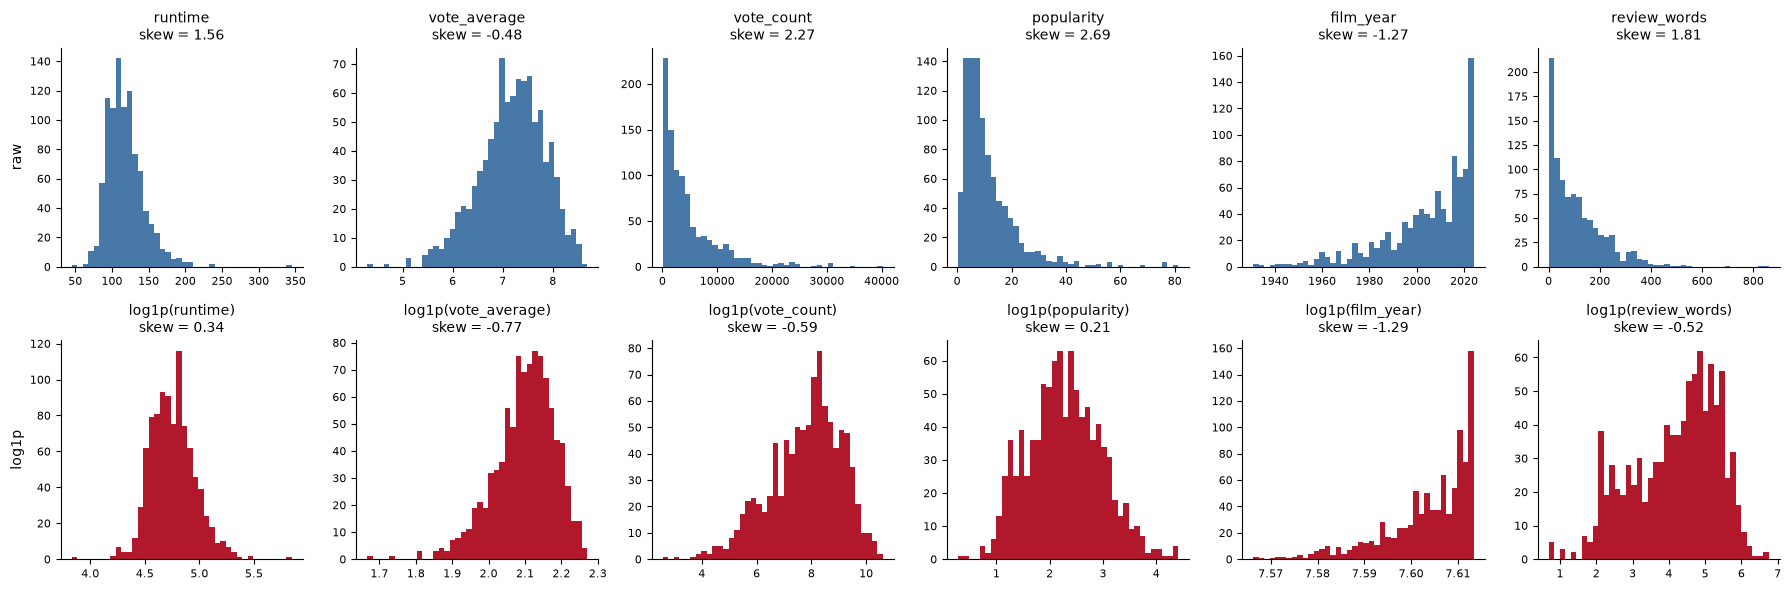

In [15]:
fig, axes = plt.subplots(2, len(CANDIDATES), figsize=(3 * len(CANDIDATES), 6))

for j, col in enumerate(CANDIDATES):
    raw = train[col].dropna()
    axes[0, j].hist(raw, bins=40, color="#4878a8")
    axes[0, j].set_title(f"{col}\nskew = {raw.skew():.2f}", fontsize=10)

    logged = np.log1p(raw)
    axes[1, j].hist(logged, bins=40, color="#b2182b")
    axes[1, j].set_title(f"log1p({col})\nskew = {logged.skew():.2f}", fontsize=10)

for ax in axes.flat:
    ax.tick_params(labelsize=8)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)

axes[0, 0].set_ylabel("raw")
axes[1, 0].set_ylabel("log1p")
plt.tight_layout()
plt.show()

Reading the skew figures (near 0 is symmetric, above ~1 is substantially
right-skewed), the decision rule is whether logging moves skew *closer* to zero:

| Feature | raw | log1p | decision |
|---|---|---|---|
| `popularity` | 2.69 | 0.21 | **log** |
| `vote_count` | 2.27 | −0.59 | **log** |
| `review_words` | 1.81 | −0.52 | **log** |
| `runtime` | 1.56 | 0.34 | **log** |
| `vote_average` | −0.48 | −0.77 | plain — logging worsens it |
| `film_year` | −1.27 | −1.29 | plain — logging is meaningless here |

`runtime` was initially assumed symmetric from the summary statistics; the histogram
shows a clear right tail (the 345-minute Lav Diaz), and the skew figure confirms
logging helps.

**Why log rather than just scale.** `StandardScaler` is a linear transform — it
changes units but leaves the distribution's *shape* untouched, so a skewed variable
stays skewed. Ridge fits one coefficient across the whole range, which without logging
forces it to treat a 3,000-vote gap identically whether it separates 12 from 3,000
(meaningful) or 37,000 from 40,000 (meaningless). Logging makes equal *ratios* span
equal distances. Log first for shape, then scale for the L2 penalty.

`log1p` rather than `log` because it computes log(1+x) and handles zero safely —
`popularity` can be 0.

`film_year`'s −1.27 skew is real and untreated. Random Forest handles it natively;
if Ridge underperforms on older films, a decade bucket or `film_age` is the fallback.


In [16]:
n_train = encode_numeric(train, PLAIN_NUMERIC, LOG_NUMERIC)
print(n_train.describe().round(2))

       vote_average  film_year  log_runtime  log_vote_count  log_popularity  \
count        953.00     953.00       953.00          953.00          953.00   
mean           7.18    2004.60         4.75            7.80            2.27   
std            0.66      18.29         0.20            1.31            0.68   
min            4.29    1931.00         3.83            2.56            0.28   
25%            6.79    1996.00         4.62            7.00            1.80   
50%            7.23    2010.00         4.74            8.00            2.24   
75%            7.64    2019.00         4.88            8.75            2.74   
max            8.69    2024.00         5.85           10.60            4.41   

       log_review_words  
count            953.00  
mean               4.18  
std                1.18  
min                0.69  
25%                3.30  
50%                4.44  
75%                5.11  
max                6.76  


### Assemble Block F

6 numeric + 15 genre + 6 language + 1 franchise flag = 28 columns.

Deliberately excluded: **director, cast, cinematographer** (high-cardinality — they
enter as historical means in Block H), **keywords** (the Model 4 rung, §13) and **overview** (Block R, §11), **`origin_country`** (near-duplicate of language).

So Model 2 answers "how much is predictable from what the film objectively *is*".
Everything about the viewer comes later.

Three checks in one cell because all three fail silently: mismatched column *order*
would misalign features without raising, and nulls surface later as an opaque `fit`
error.


In [17]:
X_train = build_features_F(train, GENRES, LANGUAGES, PLAIN_NUMERIC, LOG_NUMERIC)
X_test  = build_features_F(test,  GENRES, LANGUAGES, PLAIN_NUMERIC, LOG_NUMERIC)

print(f"train {X_train.shape}  test {X_test.shape}")
print(f"columns match: {list(X_train.columns) == list(X_test.columns)}")
print(f"nulls — train {X_train.isna().sum().sum()}, test {X_test.isna().sum().sum()}")

train (953, 28)  test (239, 28)
columns match: True
nulls — train 0, test 0


### Model 2 — Ridge

`make_pipeline` bundles the scaler with the model so scaling is fitted on train and
applied to test automatically — doing it manually invites fitting the scaler on the
full dataset, which leaks the test distribution.

`alpha=1.0` as a starting point; tuned properly with `TimeSeriesSplit` once both
families are in place, so every rung gets the same budget.


In [18]:
ridge_2 = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
ridge_2.fit(X_train, train["rating"])
pred_2r = ridge_2.predict(X_test)

results.append(evaluate(test["rating"], pred_2r, "2 — film metadata (Ridge)"))
pd.DataFrame(results).round(3)

,model,MAE,RMSE,MAE_rounded,exact,within_half
0,0 — constant (train median),0.682,0.871,0.682,0.197,0.632
1,1 — crowd score only,0.656,0.826,0.659,0.213,0.636
2,2 — film metadata (Ridge),0.600,0.778,0.592,0.268,0.695


First clear improvement. **`MAE_rounded` (0.592) beats raw MAE (0.600)** — the
first divergence, and rounding helps: continuous predictions like 3.87 snap to a real
rating. `exact` rose 21.3% → 26.8% and `within_half` 63.6% → 69.5%, so unlike Model 1
this produces genuinely more close predictions rather than only shaving large errors.


In [19]:
diff, (lo, hi) = bootstrap_mae_diff(test["rating"], pred_0, pred_2r)
print(f"Model 0 - Model 2 (Ridge): {diff:+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]")

Model 0 - Model 2 (Ridge): +0.082  95% CI [+0.027, +0.136]


In [20]:
diff, (lo, hi) = bootstrap_mae_diff(test["rating"], pred_1, pred_2r)
print(f"Model 1 - Model 2 (Ridge): {diff:+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]")

Model 1 - Model 2 (Ridge): +0.056  95% CI [+0.025, +0.090]


**Both intervals exclude zero.** Film metadata beats the baseline by 0.082
[0.027, 0.136] and beats the crowd score by 0.056 [0.025, 0.090].

The Model 1 comparison is tighter because the two models share `vote_average`, so
their errors are more correlated and pairing cancels more noise.

Note the contrast: consensus opinion alone couldn't clear zero, but structural facts
about the film — genre, runtime, era, language, reach — can.


### Model 2 — Random Forest

No scaler: trees split on rank, so scaling is irrelevant. The log transforms are also
irrelevant to a forest but harmless, and one shared feature matrix is worth more than
marginal purity.


In [21]:
rf_2 = RandomForestRegressor(n_estimators=500, random_state=0, n_jobs=-1)
rf_2.fit(X_train, train["rating"])
pred_2f = rf_2.predict(X_test)

results.append(evaluate(test["rating"], pred_2f, "2 — film metadata (RF)"))
pd.DataFrame(results).round(3)

,model,MAE,RMSE,MAE_rounded,exact,within_half
0,0 — constant (train median),0.682,0.871,0.682,0.197,0.632
1,1 — crowd score only,0.656,0.826,0.659,0.213,0.636
2,2 — film metadata (Ridge),0.600,0.778,0.592,0.268,0.695
3,2 — film metadata (RF),0.573,0.721,0.556,0.255,0.732


**The forest wins, contrary to expectation.** MAE 0.573 vs Ridge's 0.600, and
0.556 vs 0.592 once rounded. The prior reasoning — that 953 rows would be too few for a
forest to beat a well-regularised linear model — was sound but empirically wrong, which
is itself the argument for running both families rather than choosing on theory.

`exact` fell slightly (25.5% vs 26.8%) while `within_half` rose sharply (73.2% vs
69.5%), and RMSE dropped (0.721 vs 0.778). Averaging 500 trees pulls predictions toward
the middle of the distribution — costing the occasional extreme hit but avoiding
confident wrong answers. With ratings concentrated in 3.0–4.0, staying near the middle
is a good bet.


In [22]:
diff, (lo, hi) = bootstrap_mae_diff(test["rating"], pred_2r, pred_2f)
print(f"Ridge - RF (Model 2): {diff:+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]")

Ridge - RF (Model 2): +0.027  95% CI [-0.022, +0.078]


In [23]:
diff, (lo, hi) = bootstrap_mae_diff(test["rating"], pred_0, pred_2f)
print(f"Model 0 - Model 2 (RF): {diff:+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]")

Model 0 - Model 2 (RF): +0.109  95% CI [+0.040, +0.176]


**Ridge vs RF spans zero** — the families are equivalent on Block F, so both
carry forward and the ladder stays a comparison of features rather than algorithms.

**RF vs Model 0: +0.109 [0.040, 0.176]**, clearing zero comfortably.


---

## 7. Block H — personal history

Every feature here answers: *at the moment I watched this film, what did my rating
history look like?* So each row's features must be computed from **strictly earlier
rows only** — an expanding window.

**This applies to training rows as well as test rows.** Computing "mean rating for
Drama" across the whole training set and attaching it to every Drama row would let
each row see its own rating. Training fit would look excellent, test performance would
disappoint, and the feature importances would lie about what mattered.

The features are also undefined at the start — the first film has no history, the first
Korean film has no Korean history. Hence a `*_n_*` count companion for every aggregate,
so the model can distinguish a mean over one film from a mean over thirteen.


### The leakage prevention, demonstrated

`shift(1)` is the whole mechanism: it moves each rating down one position so
`expanding().mean()` at row *n* covers rows 1 to *n−1*, never row *n* itself.

Verified by hand: row 0 is NaN, row 1 equals row 0's rating, row 2 is (2.0+4.0)/2 =
3.0, row 3 is 10.5/3 = 3.5, row 4 is 14.5/4 = 3.625, row 5 is 18.5/5 = 3.7.


In [24]:
def expanding_mean(ratings):
    """Mean of all strictly-earlier values. NaN for the first row."""
    return ratings.shift(1).expanding().mean()

check = df[["watched_date", "film_title", "rating"]].head(6).copy()
check["prior_mean"] = expanding_mean(df["rating"]).head(6)
check


,watched_date,film_title,rating,prior_mean
0,2021-12-25,Don't Look Up,2.0,NaN
1,2021-12-26,Tenet,4.0,2.000
2,2021-12-26,Memories of Murder,4.5,3.000
3,2021-12-27,Dead Poets Society,4.0,3.500
4,2021-12-30,The Mitchells vs. the Machines,4.0,3.625
5,2022-01-01,Little Women,4.0,3.700


Note that rows 1 and 2 share a watched date — *Tenet* precedes *Memories of
Murder* only because of the `logged_date` tiebreaker set in `01`. Within a single day
the ordering is somewhat arbitrary, since Letterboxd does not record time of day.
A minor imprecision affecting few rows; recorded as a limitation rather than fixed.


### Grouped history

Same pattern restricted to rows sharing a key — genre, director, language, decade.

`transform` is what keeps the result aligned to the original index; `groupby().expanding()`
would return a multi-index needing reassembly. Only the **value** is shifted, never the
key — shifting both would group each row under the previous row's genre.


In [25]:
d = df[["watched_date", "film_title", "original_language", "rating"]].copy()
d["lang_prior_mean"] = expanding_group_mean(df, "original_language")

d[d["original_language"] == "ja"].head(6)

,watched_date,film_title,original_language,rating,lang_prior_mean
83,2022-03-08,Drive My Car,ja,4.5,NaN
156,2022-05-04,Perfect Blue,ja,5.0,4.500
161,2022-05-11,Paprika,ja,4.0,4.750
189,2022-06-08,House,ja,4.0,4.500
197,2022-06-16,My Neighbor Totoro,ja,5.0,4.375
203,2022-06-19,Kiki's Delivery Service,ja,5.0,4.500


Verified on Japanese-language films: *Drive My Car* NaN, *Perfect Blue* 4.5,
*Paprika* (4.5+5.0)/2 = 4.75, *House* 13.5/3 = 4.5, *Totoro* 17.5/4 = 4.375.

The non-contiguous index (83, 156, 161…) confirms alignment — `transform` mapped each
group's expanding mean back to its original row positions.


The count companion. `count()` returns **0** rather than NaN when a group exists
but has no prior rows, which is the correct semantics: "zero prior films by this
director" is a fact, not missing data.


### Genre history

Genre is multi-label, so it does not fit the `groupby` pattern — a film carries several
genres and needs its historical means aggregated across them.

An explicit loop rather than a vectorised expression. Slower, but 1,192 rows is
nothing, and the leakage logic is **visible**: the running totals update *after* the
row's features are recorded, which is the loop equivalent of `shift(1)`.

`seen` filters to genres that actually have history, so a film that is Drama (40 prior)
and War (0 prior) averages only the Drama mean rather than being dragged by an
empty one.


In [26]:
g_mean, g_exposure = genre_history(df, GENRES)

check = df[["watched_date", "film_title", "genres", "rating"]].head(8).copy()
check["genre_prior_mean"] = g_mean.head(8)
check["genre_exposure"] = g_exposure.head(8)
check

,watched_date,film_title,genres,rating,genre_prior_mean,genre_exposure
0,2021-12-25,Don't Look Up,Comedy|Science Fiction|Drama,2.0,NaN,0
1,2021-12-26,Tenet,Action|Thriller|Science Fiction,4.0,2.000000,1
2,2021-12-26,Memories of Murder,Crime|Drama|Thriller,4.5,3.000000,2
3,2021-12-27,Dead Poets Society,Drama,4.0,3.250000,2
4,2021-12-30,The Mitchells vs. the Machines,Animation|Adventure|Comedy,4.0,2.000000,1
5,2022-01-01,Little Women,Drama|Romance,4.0,3.500000,3
6,2022-01-02,"Girl, Interrupted",Drama,3.5,3.625000,4
7,2022-01-03,The Nice Guys,Comedy|Crime|Action,4.5,3.833333,4


Cross-checked independently against the raw data. *The Nice Guys* (Comedy /
Crime / Action) at row 7: Comedy mean 3.0 from two films, Crime 4.5 from one, Action
4.0 from one — average 3.833, exposure 4. Matches the function exactly.


In [27]:
for g in ["Comedy", "Crime", "Action"]:
    prior = df.iloc[:7]
    hits = prior[prior["genres"].str.contains(g, na=False)]
    print(f"{g:8s} n={len(hits)}  mean={hits['rating'].mean():.3f}  {list(hits['film_title'])}")

Comedy   n=2  mean=3.000  ["Don't Look Up", 'The Mitchells vs. the Machines']
Crime    n=1  mean=4.500  ['Memories of Murder']
Action   n=1  mean=4.000  ['Tenet']


### Imputation

Neither Ridge nor Random Forest accepts NaN, so the missing group means need filling —
and this is the decision deliberately kept explicit rather than delegated to a model's
internal NaN handling.

**The fill is `hist_mean_all`** — the running overall mean *at that point in time*.
"I know nothing about this director, so my best guess is my average rating so far."
Filling with a global constant would leak, since the global mean uses future ratings.

**The missing indicator is created before the fill**, so the information that history
was absent survives imputation. Without it, a director mean of 3.6 filled from the
running average is indistinguishable from a director genuinely rated 3.6.

**`hist_mean_all` is filled first** so the fallback is complete before the loop uses
it. An earlier version filled it last, leaving four NaNs on row 1.

**Counts are filled with 0** for films whose key is missing entirely — the 15 films
with no cinematographer credit have no group at all, so `transform` returns NaN rather
than 0.

Row 1's `hist_mean_all` cannot be filled from itself and uses the column median, which
does technically peek at later values. It affects one row of 1,192; the alternative is
discarding the first film. Noted as a limitation.


### Assemble Block H

`impute_history` is called inside `build_features_H`, so one call returns a finished
block. Prefixes are passed as an argument rather than read from a global, so genre —
which is not in `HISTORY_KEYS` — is handled by the same code path.

Computed on the **full chronological frame** then split, never on train and test
separately: the first test film has 953 films of history behind it, and computing the
blocks independently would wrongly give it none.


In [28]:
H_all = build_features_H(df, GENRES, HISTORY_KEYS)

print(H_all.shape)
print(f"remaining nulls: {H_all.isna().sum().sum()}")
print()
print(H_all.filter(like="_missing").sum())

(1192, 18)
remaining nulls: 0

hist_mean_all_missing         1
hist_mean_dir_missing       581
hist_mean_dop_missing       610
hist_mean_lang_missing       27
hist_mean_decade_missing     11
hist_mean_genre_missing       6
dtype: int64


**Missing-history counts:** director 581 (49% of films are by a
director not seen before), cinematographer 610, genre 6, language 27, decade 11,
overall 1.

The director figure matches the EDA sparsity finding — 281 of 484 training directors
appear exactly once — and is the reason the `*_n_*` companions are load-bearing rather
than decorative.


---

## 8. Model 3 — film metadata + personal history

Block F and Block H combined. `H_all` was computed on the full chronological frame, so it
is **sliced** at the split rather than rebuilt — the first test film keeps its 953 films
of history.

Two kinds of feature, two different leakage risks. `build_features_F` runs on the whole
frame safely because it contains no cross-row aggregation: each film's genre and runtime
depend only on that film. Block H does aggregate across rows, which is exactly why it
needed the expanding window.


In [29]:
X3_all = pd.concat([build_features_F(df, GENRES, LANGUAGES, PLAIN_NUMERIC, LOG_NUMERIC), H_all], axis=1)

X3_train = X3_all[:split_idx]
X3_test  = X3_all[split_idx:]

print(f"train {X3_train.shape}  test {X3_test.shape}")
print(f"columns match: {list(X3_train.columns) == list(X3_test.columns)}")
print(f"nulls — train {X3_train.isna().sum().sum()}, test {X3_test.isna().sum().sum()}")

train (953, 46)  test (239, 46)
columns match: True
nulls — train 0, test 0


### Ridge

Same `alpha=1.0` as Model 2, deliberately. If the alpha changed between rungs, any
improvement could be the tuning rather than the features. Like-for-like comparison is
Model 2 **Ridge**, not the forest.


In [30]:
ridge_3 = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
ridge_3.fit(X3_train, train["rating"])
pred_3r = ridge_3.predict(X3_test)

results.append(evaluate(test["rating"], pred_3r, "3 — + history (Ridge)"))
pd.DataFrame(results).round(3)

,model,MAE,RMSE,MAE_rounded,exact,within_half
0,0 — constant (train median),0.682,0.871,0.682,0.197,0.632
1,1 — crowd score only,0.656,0.826,0.659,0.213,0.636
2,2 — film metadata (Ridge),0.600,0.778,0.592,0.268,0.695
3,2 — film metadata (RF),0.573,0.721,0.556,0.255,0.732
4,3 — + history (Ridge),0.593,0.741,0.582,0.238,0.720


MAE barely moved (0.600 → 0.593), but **RMSE dropped much more** (0.778 → 0.741).
RMSE squares each error, so it is dominated by the large misses; MAE weights every film
equally. So history fixed some of Ridge's worst predictions without improving typical ones.


In [31]:
diff, (lo, hi) = bootstrap_mae_diff(test["rating"], pred_2r, pred_3r)
print(f"Model 2 - Model 3 (Ridge): {diff:+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]")

Model 2 - Model 3 (Ridge): +0.007  95% CI [-0.031, +0.045]


**Spans zero.** For Ridge, history adds nothing detectable.

A plausible reason: Ridge is the family least suited to Block H. A director mean only
means something *conditional* on its count — 4.5 over twelve films is strong, 4.5 over one
film is noise. Ridge adds the mean and the count as independent terms, so it cannot
express "trust the mean only when n is high". A forest can, by splitting on both.


### Random Forest

In [32]:
rf_3 = RandomForestRegressor(n_estimators=500, random_state=0, n_jobs=-1)
rf_3.fit(X3_train, train["rating"])
pred_3f = rf_3.predict(X3_test)

results.append(evaluate(test["rating"], pred_3f, "3 — + history (RF)"))
pd.DataFrame(results).round(3)

,model,MAE,RMSE,MAE_rounded,exact,within_half
0,0 — constant (train median),0.682,0.871,0.682,0.197,0.632
1,1 — crowd score only,0.656,0.826,0.659,0.213,0.636
2,2 — film metadata (Ridge),0.600,0.778,0.592,0.268,0.695
3,2 — film metadata (RF),0.573,0.721,0.556,0.255,0.732
4,3 — + history (Ridge),0.593,0.741,0.582,0.238,0.720
5,3 — + history (RF),0.570,0.732,0.548,0.272,0.753


In [33]:
diff, (lo, hi) = bootstrap_mae_diff(test["rating"], pred_2f, pred_3f)
print(f"Model 2 - Model 3 (RF): {diff:+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]")

Model 2 - Model 3 (RF): +0.002  95% CI [-0.032, +0.039]


**Also spans zero** — and RMSE actually worsened slightly (0.721 → 0.732).

**The hypothesis above did not hold.** The forest was expected to exploit the conditional
structure that Ridge could not, and it did not. Recorded rather than rationalised.

### Reframing what Model 2 is

Model 2 is not impersonal. It is trained on *these* ratings, so when it learns a positive
weight on `genre_Drama` and a negative one on `genre_Action`, that **is** a model of this
viewer's taste. The personalisation already happened at Model 2.

Block H then re-derives largely the same information — "my historical mean rating for
Drama" — by a different route. If preferences are stable across the training period, a
static fitted model captures them as well as a running average does, and better than one
that is noisy in the early rows.

So Block H can only add what a static model **cannot** learn: per-director preferences
(too sparse, median one film) or genuine taste change over time (modest).


## 9. Diagnosing the null result

### Impurity-based importance

Checking whether the forest is ignoring Block H or using it in a way that nets out.
Block H is 18 of 46 features, so proportional importance would be ~39%.


In [34]:
imp = pd.Series(rf_3.feature_importances_, index=X3_train.columns).sort_values(ascending=False)

print("top 15 features:")
print(imp.head(15).round(4))
print()
h_cols = [c for c in imp.index if c.startswith("hist_")]
print(f"Block H share of total importance: {imp[h_cols].sum():.1%}  ({len(h_cols)} of {len(imp)} features)")

top 15 features:
vote_average        0.2339
hist_mean_dir       0.0994
log_runtime         0.0565
hist_mean_genre     0.0565
hist_n_decade       0.0560
log_review_words    0.0553
hist_mean_decade    0.0486
log_popularity      0.0483
log_vote_count      0.0463
film_year           0.0441
hist_n_lang         0.0354
hist_mean_dop       0.0322
hist_n_genre        0.0305
hist_mean_lang      0.0267
hist_mean_all       0.0261
dtype: float64

Block H share of total importance: 45.7%  (18 of 46 features)


**45.7% — more than proportional**, with `hist_mean_dir` second overall. The
forest is not ignoring Block H.

But this measure (MDI, `feature_importances_`) is misleading here for two reasons:

- **It is biased toward continuous features.** It totals impurity reduction across every
  split, and continuous features offer far more candidate split points than binary ones.
  Every Block H feature is continuous; every genre and language feature is binary.
- **It measures fitting, not generalising.** It is computed from training data, so a
  feature can be used heavily to fit training *noise* and contribute nothing on unseen
  films.

A further problem specific to the count features: **trees cannot extrapolate.**
`hist_n_decade` grows steadily over time, so every test film carries a count larger than
anything seen in training, and the forest lumps them all into the leaf covering the
training maximum.


### Permutation importance on the test set

Shuffle one feature at a time and measure how much *test* error worsens. This measures
what actually helps on unseen films and is not biased toward continuous features.

`n_repeats=20` because a single shuffle is noisy on 239 films. Negative values would
mean the model was actively misled by a feature.


In [35]:
perm = permutation_importance(rf_3, X3_test, test["rating"],
                              scoring="neg_mean_absolute_error",
                              n_repeats=20, random_state=0, n_jobs=-1)

pi = pd.Series(perm.importances_mean, index=X3_test.columns).sort_values(ascending=False)
print("top 15 by test-set permutation importance (MAE increase when shuffled):")
print(pi.head(15).round(4))
print()
h_cols = [c for c in pi.index if c.startswith("hist_")]
print(f"Block H total: {pi[h_cols].sum():+.4f}   Block F total: {pi.drop(h_cols).sum():+.4f}")

top 15 by test-set permutation importance (MAE increase when shuffled):
vote_average        0.0654
hist_mean_dir       0.0487
film_year           0.0139
hist_n_decade       0.0123
hist_n_lang         0.0074
hist_mean_genre     0.0051
hist_mean_decade    0.0039
log_popularity      0.0036
hist_mean_dop       0.0031
genre_Drama         0.0013
log_vote_count      0.0012
genre_History       0.0011
genre_Action        0.0010
log_review_words    0.0008
hist_n_genre        0.0007
dtype: float64

Block H total: +0.0803   Block F total: +0.0813


`hist_mean_dir` has **genuine** test-set importance (0.049), second only to
`vote_average`. So the forest is not merely memorising noise with it.

This deepens the puzzle rather than resolving it, and exposes a limitation worth stating:
**permutation importance measures what a model relies on, not what a feature adds.** When
features carry overlapping information, the model splits its reliance between them —
remove one and it leans harder on the others. So importance *within* Model 3 can be large
while the marginal gain over Model 2 is zero.

The hypothesised overlap: directors rated highly here are mostly also crowd-acclaimed, so
director history and `vote_average` may say the same thing.

Checked on **training** data only, restricted to films with genuine director history so
imputed rows don't inflate the correlation.


In [36]:
tr = X3_train[X3_train["hist_mean_dir_missing"] == 0]
print(f"training films with real director history: {len(tr)}")
print(f"corr(hist_mean_dir, vote_average): {tr['hist_mean_dir'].corr(tr['vote_average']):.3f}")
print(f"corr(hist_mean_dir, rating):       {tr['hist_mean_dir'].corr(train.loc[tr.index, 'rating']):.3f}")
print(f"corr(vote_average, rating):        {tr['vote_average'].corr(train.loc[tr.index, 'rating']):.3f}")

training films with real director history: 469
corr(hist_mean_dir, vote_average): 0.173
corr(hist_mean_dir, rating):       0.411
corr(vote_average, rating):        0.452


**The overlap hypothesis is falsified.** Director history and crowd score correlate
at only 0.173 — largely independent signals. And director history predicts rating (0.411)
almost as strongly as the crowd score does (0.452).

So in training, director history is a strong predictor carrying information the crowd
score lacks — which makes the null ablation genuinely hard to explain. Explanations still
standing:

1. **It applies to only half the films.** On the other half it is an imputed fallback,
   capping the achievable gain.
2. **The plausible gain may sit below what 239 films can detect.** The interval was
   [−0.032, +0.039].
3. **The other Block H features may be diluting it** — particularly the counts, which
   cannot extrapolate.

**A deliberate constraint.** The tempting move is to try Block F plus only the director
features and report the best subset on the test set. That would turn the test set into a
tuning set and invalidate it as an honest estimate. The ablation above is the
pre-registered comparison and its answer stands; these diagnostics **explain** it, they do
not overturn it.


### Testing dilution — inside the training period

Explanation 3 is testable without touching the test set, using **cross-validation within
training**. `TimeSeriesSplit` always trains on earlier films and validates on later ones,
preserving the chronological logic, and gives five estimates instead of one.


In [37]:
tscv = TimeSeriesSplit(n_splits=5)

f_cols   = list(build_features_F(df, GENRES, LANGUAGES, PLAIN_NUMERIC, LOG_NUMERIC).columns)
dir_cols = ["hist_mean_dir", "hist_n_dir", "hist_mean_dir_missing"]

candidates = {
    "F only":        f_cols,
    "F + director":  f_cols + dir_cols,
    "F + all H":     list(X3_train.columns),
}

y_tr = train["rating"].values
for name, cols in candidates.items():
    maes = []
    for fit_idx, val_idx in tscv.split(X3_train):
        rf = RandomForestRegressor(n_estimators=300, random_state=0, n_jobs=-1)
        rf.fit(X3_train.iloc[fit_idx][cols], y_tr[fit_idx])
        pred = rf.predict(X3_train.iloc[val_idx][cols])
        maes.append(np.abs(y_tr[val_idx] - pred).mean())
    print(f"{name:14s} CV MAE {np.mean(maes):.3f}  (folds: {' '.join(f'{m:.3f}' for m in maes)})")

F only         CV MAE 0.597  (folds: 0.623 0.573 0.550 0.636 0.604)
F + director   CV MAE 0.589  (folds: 0.615 0.570 0.566 0.613 0.579)
F + all H      CV MAE 0.614  (folds: 0.637 0.653 0.602 0.596 0.581)


Dilution is supported:

- **Director history alone helps slightly** — 0.589 vs 0.597, better in four of five folds.
- **Full Block H is worse than no history at all** — 0.614. The other fifteen history
  features actively degrade the forest on average.

The fold pattern is the most interesting part:

| Fold | F only | F + all H | |
|---|---|---|---|
| 1 | 0.623 | 0.637 | worse |
| 2 | 0.573 | 0.653 | much worse |
| 3 | 0.550 | 0.602 | worse |
| 4 | 0.636 | 0.596 | **better** |
| 5 | 0.604 | 0.581 | **better** |

Full history **hurts in the early folds and helps in the late ones**. The first fold trains
on ~160 films, where history features are overwhelmingly imputed fallbacks — noise. By the
later folds history has accumulated and the features carry signal.

Not monotonic, and five folds with this spread is thin evidence — suggestive rather than
established. But a meaningful idea: **personal history features need history before they
pay off.**


---

## 10. Hyperparameter tuning

The full-history forest has 46 features and may simply be under-regularised. Tuning is
needed anyway, and is applied with an **identical budget to every rung** so the
comparison stays about features.

Grid search over the same time-ordered folds, inside training only. The test set is
untouched until the winning model is refitted.

- **`min_samples_leaf`** stops the forest carving leaves that fit a handful of films —
  directly relevant to noisy history features, since a leaf built on three films fits noise.
- **`max_features`** limits how many features each split considers, forcing trees to use a
  wider spread rather than repeatedly grabbing the same continuous ones.
- **`ridge__alpha`** — double underscore addresses a parameter of a named pipeline step.

`GridSearchCV` refits the winner on all 953 training films before returning it.


In [38]:
RIDGE_GRID = {"ridge__alpha": [0.1, 1, 10, 100, 1000]}
RF_GRID = {
    "min_samples_leaf": [1, 5, 15, 30],
    "max_features":     ["sqrt", 0.5, 1.0],
}

def tune(estimator, grid, X, y):
    """Grid search over time-ordered folds; returns the refitted best model."""
    search = GridSearchCV(estimator, grid, cv=tscv,
                          scoring="neg_mean_absolute_error", n_jobs=-1)
    search.fit(X, y)
    print(f"  best {search.best_params_}  CV MAE {-search.best_score_:.3f}")
    return search.best_estimator_

print("Model 2 — Ridge")
ridge_2t = tune(make_pipeline(StandardScaler(), Ridge()), RIDGE_GRID, X_train, train["rating"])

print("Model 2 — RF")
rf_2t = tune(RandomForestRegressor(n_estimators=300, random_state=0),
             RF_GRID, X_train, train["rating"])

Model 2 — Ridge
  best {'ridge__alpha': 100}  CV MAE 0.602
Model 2 — RF
  best {'max_features': 0.5, 'min_samples_leaf': 1}  CV MAE 0.590


Ridge wanted **much** stronger regularisation (alpha 100 vs the default 1): 28
correlated features on 953 rows generalise better with harder shrinkage. The forest chose
`max_features=0.5` but kept leaves unrestricted — for Block F it benefits from decorrelating
trees rather than from smoothing.


In [39]:
print("Model 3 — Ridge")
ridge_3t = tune(make_pipeline(StandardScaler(), Ridge()), RIDGE_GRID, X3_train, train["rating"])

print("Model 3 — RF")
rf_3t = tune(RandomForestRegressor(n_estimators=300, random_state=0),
             RF_GRID, X3_train, train["rating"])

Model 3 — Ridge
  best {'ridge__alpha': 100}  CV MAE 0.607
Model 3 — RF
  best {'max_features': 0.5, 'min_samples_leaf': 5}  CV MAE 0.589


**The forest raised `min_samples_leaf` from 1 to 5** once given the full history
block — exactly the regularisation predicted, absorbing the noisy history features. Its CV
MAE fell to 0.589, matching the director-only variant.

But note what tuning did **not** do. Tuned F scores 0.590, tuned F + H 0.589 — a difference
of 0.001. The noise is gone; no gain appeared in its place. Ridge went slightly the other
way (0.602 → 0.607).


### Tuned models on the test set

Untuned rows are kept in the table deliberately — the contrast shows tuning was applied
evenly and what it changed. **The tuned figures are the headline results.**


In [40]:
tuned = {
    "2 — metadata (Ridge, tuned)": (ridge_2t, X_train.columns),
    "2 — metadata (RF, tuned)":    (rf_2t,    X_train.columns),
    "3 — + history (Ridge, tuned)": (ridge_3t, X3_train.columns),
    "3 — + history (RF, tuned)":    (rf_3t,    X3_train.columns),
}

preds_t = {}
for name, (model, cols) in tuned.items():
    X_te = X_test if len(cols) == X_test.shape[1] else X3_test
    preds_t[name] = model.predict(X_te)
    results.append(evaluate(test["rating"], preds_t[name], name))

pd.DataFrame(results).round(3)

,model,MAE,RMSE,MAE_rounded,exact,within_half
0,0 — constant (train median),0.682,0.871,0.682,0.197,0.632
1,1 — crowd score only,0.656,0.826,0.659,0.213,0.636
2,2 — film metadata (Ridge),0.600,0.778,0.592,0.268,0.695
3,2 — film metadata (RF),0.573,0.721,0.556,0.255,0.732
4,3 — + history (Ridge),0.593,0.741,0.582,0.238,0.720
5,3 — + history (RF),0.570,0.732,0.548,0.272,0.753
6,"2 — metadata (Ridge, tuned)",0.595,0.766,0.579,0.272,0.711
7,"2 — metadata (RF, tuned)",0.566,0.716,0.554,0.251,0.745
8,"3 — + history (Ridge, tuned)",0.575,0.716,0.571,0.209,0.762
9,"3 — + history (RF, tuned)",0.554,0.717,0.544,0.276,0.753


Tuning improved every model and widened the gap between rungs. "History adds" is the
paired bootstrap difference, which can differ by 0.001 from subtracting the rounded MAEs:

| | Model 2 | Model 3 | History adds (paired) |
|---|---|---|---|
| Ridge, untuned | 0.600 | 0.593 | 0.007 |
| Ridge, tuned | 0.595 | 0.575 | 0.020 |
| RF, untuned | 0.573 | 0.570 | 0.002 |
| RF, tuned | 0.566 | **0.554** | 0.011 |

**Caution on the Ridge figure.** In CV, tuned Ridge said history made things slightly
*worse*; on test it says history helps by 0.020. When CV and test disagree on direction,
the honest reading is that the true effect is small and both numbers are noise around it.

Tuned Model 3 Ridge also shows **prediction compression**: `exact` falls to 20.9%, the
lowest of any fitted model, while `within_half` rises to 76.2%. Alpha 100 shrinks
predictions toward the mean — rarely landing on the exact rating, rarely straying far.


In [41]:
pairs = [
    ("Ridge: M1  vs M2t", pred_1,                                  preds_t["2 — metadata (Ridge, tuned)"]),
    ("RF:    M1  vs M2t", pred_1,                                  preds_t["2 — metadata (RF, tuned)"]),
    ("Ridge: M2t vs M3t", preds_t["2 — metadata (Ridge, tuned)"], preds_t["3 — + history (Ridge, tuned)"]),
    ("RF:    M2t vs M3t", preds_t["2 — metadata (RF, tuned)"],    preds_t["3 — + history (RF, tuned)"]),
    ("RF:    M0  vs M3t", pred_0,                                  preds_t["3 — + history (RF, tuned)"]),
    ("RF:    M1  vs M3t", pred_1,                                  preds_t["3 — + history (RF, tuned)"]),
]

for label, a, b in pairs:
    diff, (lo, hi) = bootstrap_mae_diff(test["rating"], a, b)
    flag = "  *" if lo > 0 else ""
    print(f"{label}: {diff:+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]{flag}")

Ridge: M1  vs M2t: +0.061  95% CI [+0.030, +0.092]  *
RF:    M1  vs M2t: +0.091  95% CI [+0.043, +0.139]  *
Ridge: M2t vs M3t: +0.020  95% CI [-0.013, +0.056]
RF:    M2t vs M3t: +0.011  95% CI [-0.019, +0.043]
RF:    M0  vs M3t: +0.127  95% CI [+0.066, +0.189]  *
RF:    M1  vs M3t: +0.102  95% CI [+0.049, +0.156]  *


---

## Model 3 — conclusions

**Personal history adds nothing detectable on top of film metadata.** Positive in both
families (+0.020 Ridge, +0.011 RF), significant in neither. Both pointing the same way is
mildly suggestive, but they are evaluated on the same 239 films with overlapping features,
so they are not independent evidence and are not combined into a stronger claim.

Film metadata alone, tuned, beats the crowd score in both families — RF +0.091 [0.043,
0.139], Ridge +0.061 [0.030, 0.092] — confirming the untuned result from §6.

**The best model beats the crowd score by 0.102 stars**, 95% CI [0.049, 0.156] — the
project's headline answer to "beyond the crowd score".

**The personalisation happens at Model 2, not Model 3.** A model fitted on these ratings
learns this viewer's taste from film metadata alone. Re-deriving that taste as explicit
history features adds little, because preferences are stable enough that the fitted model
already captures them. Most history features are noise at this scale; director history is
the one consistent signal; and history appears to need accumulated history before it pays
off.

| Model | MAE (tuned) | vs Model 0 | vs Model 1 |
|---|---|---|---|
| 0 — constant | 0.682 | — | — |
| 1 — crowd score | 0.656 | not significant | — |
| 2 — metadata (RF) | 0.566 | not computed (tuned) | +0.091 [0.043, 0.139] |
| 3 — + history (RF) | **0.554** | +0.127 [0.066, 0.189] | +0.102 [0.049, 0.156] |

**Next:** Block R — review-derived features, starting with R1 (TF-IDF + Ridge).


---

## 11. Block R — review text

Planned as the final rung: does what the viewer has *written* add anything beyond what
they have *rated*? Explored in depth, because the reviews are the most personal data in the
project. It produced no legitimate predictive feature, and the reasons why are the finding.

**The governing rule:** a film's own review can never inform its own prediction — it was
written after the opinion formed. Review information may only reach an unseen film through
something that film already has.

### 11.1 R1 — which words go with high and low ratings

TF-IDF on training reviews only, then Ridge against rating. Vectoriser choices:

- `stop_words="english"` drops frequent, meaningless words
- `ngram_range=(1, 2)` keeps phrases, so "not good" survives as a unit
- `min_df=5` — a word used once identifies a film rather than a response
- `max_df=0.8` — near-universal words don't discriminate
- `sublinear_tf=True` — 1 + log(count), so repetition doesn't dominate a review


In [42]:
tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.8,
    sublinear_tf=True,
)

T_train = tfidf.fit_transform(train["review_clean"].fillna(""))
r1 = Ridge(alpha=1.0).fit(T_train, train["rating"])

vocab = np.array(tfidf.get_feature_names_out())
coefs = pd.Series(r1.coef_, index=vocab).sort_values()

print(f"vocabulary: {len(vocab)} terms from {T_train.shape[0]} training reviews\n")
print("words predicting LOW ratings:")
print(coefs.head(20).round(3).to_string())
print("\nwords predicting HIGH ratings:")
print(coefs.tail(20)[::-1].round(3).to_string())

vocabulary: 2210 terms from 953 training reviews

words predicting LOW ratings:
interesting     -1.205
end             -1.201
worst           -1.048
devil           -1.043
continues       -1.042
absolutely      -0.960
ryan            -0.959
worse           -0.913
pretty          -0.910
bad             -0.909
boring          -0.908
ends            -0.907
awful           -0.864
think           -0.834
entertaining    -0.788
wish            -0.776
tv              -0.772
unfortunately   -0.764
decent          -0.744
crimes          -0.733

words predicting HIGH ratings:
people        0.983
perfect       0.918
favourites    0.917
life          0.873
perfectly     0.800
scream        0.772
sense         0.732
ve seen       0.731
best          0.719
park          0.716
brilliant     0.710
seen          0.710
longer        0.700
free          0.699
incredible    0.655
easy          0.648
score         0.647
black         0.633
films         0.629
understand    0.624


**The strongest low-rating signal is "interesting"** — not "bad" or "boring". Read it
alongside *pretty, decent, entertaining, think*: **hedging vocabulary.** Faint praise
reliably marks a low rating for this viewer.

The high end is superlatives — *perfect, favourites, best, brilliant, incredible* — plus
*ve seen* ("one of the best I've seen"). *score* also appears: praising the music predicts a
high rating.

A minority of terms identify films rather than responses — *ryan, devil, crimes, park,
scream* are most likely names and titles.

### 11.2 How much do reviews encode ratings?

Predicting each test film from **its own review** — deliberately leaky, and never a model
in the results table. Tuned inside training like everything else.


In [43]:
T_test = tfidf.transform(test["review_clean"].fillna(""))

search = GridSearchCV(Ridge(), {"alpha": [0.1, 1, 3, 10, 30, 100]},
                      cv=tscv, scoring="neg_mean_absolute_error")
search.fit(T_train, train["rating"])
print(f"best alpha {search.best_params_['alpha']}  CV MAE {-search.best_score_:.3f}")

r1 = search.best_estimator_
pred_leaky = r1.predict(T_test)
ev = evaluate(test["rating"], pred_leaky, "LEAKY — film's own review (tuned)")
print(pd.DataFrame([ev]).round(3).to_string(index=False))

best alpha 1  CV MAE 0.629
                            model   MAE  RMSE  MAE_rounded  exact  within_half
LEAKY — film's own review (tuned) 0.595 0.771        0.598  0.255        0.711


Tuning chose alpha 1, so the model was already near its best. **Text alone: MAE
0.595** — weaker than film metadata (0.566), even with each film's own review available.

The fair reading is narrow: *review text on its own, as bag-of-words, is a weaker signal
than film metadata.* It does not show that reviews add nothing — a leaky model combining
text **with** metadata would very likely beat both. Bag-of-words also loses negation,
sarcasm and hedging, so it under-reads verdicts a human would find obvious.

### 11.3 Hand-picked aspects — tried and rejected

A fixed lexicon of film aspects, checking whether mentioning one goes with a different
rating.


In [44]:
ASPECTS = {
    "cinematography": r"cinematograph|visual|shot|framing|camera|colou?r",
    "acting":         r"\bacting\b|performance|\bcast\b|portray",
    "story":          r"\bstory\b|plot|narrative|script|screenplay|writing",
    "characters":     r"character",
    "pacing":         r"pacing|paced|\bslow\b|\bdrag|overlong",
    "music":          r"\bscore\b|soundtrack|music",
}

text = train["review_clean"].fillna("").str.lower()
rows = []
for name, pat in ASPECTS.items():
    hit = text.str.contains(pat, regex=True)
    rows.append({
        "aspect": name,
        "mentioned": int(hit.sum()),
        "rating_if_mentioned": train.loc[hit, "rating"].mean(),
        "rating_if_not":       train.loc[~hit, "rating"].mean(),
    })

asp = pd.DataFrame(rows)
asp["difference"] = asp["rating_if_mentioned"] - asp["rating_if_not"]
print(asp.round(3).to_string(index=False))

        aspect  mentioned  rating_if_mentioned  rating_if_not  difference
cinematography        220                3.702          3.546       0.156
        acting        259                3.593          3.579       0.014
         story        266                3.543          3.598      -0.054
    characters        181                3.530          3.595      -0.064
        pacing         62                3.532          3.586      -0.054
         music        107                3.734          3.563       0.170


Two aspects separate — **cinematography (+0.156)** and **music (+0.170)**; the rest
sit within ±0.07.

**Rejected as an approach.** The lexicon is a generic guess at what matters in film
reviews — the same six words for anyone — rather than something learned from this
viewer's writing. The mentions also come from each film's *own* review, so can't be used
directly; attaching them via genre would duplicate the genre one-hots, and via director or
cinematographer runs into the median-one-film sparsity that limited Block H.

### 11.4 Shared vocabulary with TMDB text — tried and rejected

Restricting R1 to words appearing in **both** the viewer's reviews and TMDB descriptions,
so that learned weights could later be applied to an unseen film's overview and keywords.


In [45]:
films_text = (df["overview"].fillna("") + " " +
              df["keywords"].fillna("").str.replace("|", " ", regex=False))
train_tmdb = films_text[:split_idx]

rev_vec  = TfidfVectorizer(stop_words="english", min_df=5).fit(train["review_clean"].fillna(""))
tmdb_vec = TfidfVectorizer(stop_words="english", min_df=5).fit(train_tmdb)

rev_terms, tmdb_terms = set(rev_vec.get_feature_names_out()), set(tmdb_vec.get_feature_names_out())
shared = sorted(rev_terms & tmdb_terms)

print(f"review vocabulary: {len(rev_terms)}   TMDB vocabulary: {len(tmdb_terms)}   shared: {len(shared)}")
print()
print(shared[:80])

review vocabulary: 1953   TMDB vocabulary: 1927   shared: 714

['10', '20', 'able', 'abuse', 'act', 'action', 'actor', 'actress', 'adult', 'adventure', 'age', 'aged', 'ago', 'air', 'alien', 'alive', 'allegory', 'alongside', 'ambition', 'ambitious', 'america', 'american', 'animals', 'animation', 'anna', 'answers', 'anti', 'anxiety', 'apart', 'appears', 'art', 'artificial', 'artist', 'artistic', 'attempt', 'attempts', 'attention', 'away', 'baby', 'bad', 'based', 'battle', 'beautiful', 'beauty', 'begin', 'begins', 'belief', 'believe', 'believes', 'beneath', 'best', 'better', 'big', 'biggest', 'black', 'bleak', 'blood', 'body', 'bond', 'book', 'born', 'bound', 'boy', 'break', 'breaking', 'brilliant', 'bring', 'brings', 'british', 'broken', 'brought', 'brutal', 'build', 'building', 'built', 'burn', 'burning', 'called', 'capture', 'car']


In [46]:
rev_shared = TfidfVectorizer(vocabulary=shared, sublinear_tf=True)
S_train = rev_shared.fit_transform(train["review_clean"].fillna(""))

search = GridSearchCV(Ridge(), {"alpha": [0.3, 1, 3, 10, 30]},
                      cv=tscv, scoring="neg_mean_absolute_error")
search.fit(S_train, train["rating"])
r1s = search.best_estimator_
print(f"best alpha {search.best_params_['alpha']}  CV MAE {-search.best_score_:.3f}\n")

coefs_s = pd.Series(r1s.coef_, index=shared).sort_values()
print("subjects I respond to BADLY:")
print(coefs_s.head(20).round(3).to_string())
print("\nsubjects I respond to WELL:")
print(coefs_s.tail(20)[::-1].round(3).to_string())

best alpha 3  CV MAE 0.657

subjects I respond to BADLY:
bad        -0.967
end        -0.855
ends       -0.824
think      -0.591
instead    -0.573
doesn      -0.523
gets       -0.493
tv         -0.491
couple     -0.460
dad        -0.438
hand       -0.436
surprise   -0.430
just       -0.427
going      -0.425
attempt    -0.425
don        -0.424
decide     -0.412
point      -0.410
nearly     -0.408
times      -0.408

subjects I respond to WELL:
life         0.788
people       0.680
seen         0.631
brilliant    0.614
perfect      0.546
day          0.538
modern       0.530
finally      0.528
park         0.524
sense        0.515
far          0.511
michael      0.485
lives        0.465
hilarious    0.443
best         0.439
longer       0.437
chilling     0.428
films        0.427
lost         0.424
world        0.423


**It failed.** The surviving weights are still evaluative (*bad, brilliant, perfect*)
or structural (*end, ends, instead*, and *doesn* / *don* — negation fragments), with very
little subject matter. The same token also does a different job in each source: *end* in a
review means "the ending was weak"; in an overview it means where the plot goes.

**CV MAE 0.657 is an upper bound** — this is still predicting from each film's *own*
review, just restricted to transferable words — and it sits at roughly the crowd-score
baseline. A feature built by applying these weights to TMDB text could only be a degraded
copy of a signal that is already close to nothing.

**The deeper objection** is conceptual: an overview is an objective description of a film,
a review is a subjective judgement formed after watching it. Matching one against the
other — by tokens or by embeddings — assumes a relationship that isn't there.

### 11.5 Do reviews know what Model 3 doesn't?

Model 3's out-of-fold errors on training films, then a Ridge on review text to predict
those errors, applied to each test film's own review. **Leaky by design, diagnostic only.**

`KFold` rather than `TimeSeriesSplit` because every training row needs an out-of-fold
prediction and `TimeSeriesSplit` never predicts its first fold. That lets later films
inform earlier ones — acceptable for a diagnostic, not for a feature.


In [47]:
y_tr = train["rating"].values
oof_3 = cross_val_predict(clone(rf_3t), X3_train, y_tr, cv=KFold(5))
resid_tr = y_tr - oof_3

search = GridSearchCV(Ridge(), {"alpha": [1, 3, 10, 30, 100]},
                      cv=KFold(5), scoring="neg_mean_absolute_error")
search.fit(T_train, resid_tr)
resid_model = search.best_estimator_
print(f"best alpha {search.best_params_['alpha']}")

base    = preds_t["3 — + history (RF, tuned)"]
boosted = base + resid_model.predict(T_test)

print(f"Model 3 (RF, tuned)                MAE {np.abs(test['rating'] - base).mean():.3f}")
print(f"  + own-review correction (LEAKY)  MAE {np.abs(test['rating'] - boosted).mean():.3f}")
diff, (lo, hi) = bootstrap_mae_diff(test["rating"], base, boosted)
print(f"  improvement {diff:+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]")

best alpha 1
Model 3 (RF, tuned)                MAE 0.554
  + own-review correction (LEAKY)  MAE 0.540
  improvement +0.014  95% CI [-0.021, +0.048]


**Spans zero** — +0.014 [−0.021, +0.048].

This is weaker evidence than it looks, for two reasons. Bag-of-words demonstrably
under-reads verdicts (§11.2), so a null here says as much about TF-IDF as about the
reviews. And the test cannot separate the review's *verdict* (never transferable) from its
*reasons* (potentially transferable), so neither a positive nor a null result would settle
whether transferable information exists.

The like-for-like alternative — applying the viewer's weights to **other people's**
reviews of an unseen film — is documented in `02` §11. The idea is sound; only 32% of
viewings have three or more TMDB reviews written before the watch date, below the
pre-set 50% threshold.

### 11.6 Block R — conclusion

| Approach | Why it fails |
|---|---|
| Hand-picked aspects | Generic, not personal |
| Shared vocabulary with TMDB text | A description is not an opinion |
| Residual upper bound | Bag-of-words can't read verdicts well enough to settle it |
| Viewer's weights on others' reviews | Sound bridge; too sparse before watch dates |

**In a single-user setting, reviews can only reach an unseen film through something that
film already has, and every available bridge is either conceptually unjustified or too
sparse at this scale.** A structural property of the problem, not a failure of technique.

What the reviews *do* reveal: **ratings are encoded in how the viewer writes about films —
verdicts, hedging, whether they dwell on the ending — not in what films are about.** The
subject-matter side of taste is already captured by Block F, the same conclusion Block H
reached from the other direction.

The reviews are carried into the Streamlit app as **explanation** rather than prediction:
alongside a prediction, the viewer's own reviews of the most similar films they have rated.

---

## 12. How accurate is the best model?

Evaluated on **Model 3**, the best model at this point; re-run on the deployment model
in §14. MAE averages over very different
kinds of film, so error is broken down by the viewer's actual rating.


In [48]:
best = preds_t["3 — + history (RF, tuned)"]
ev = pd.DataFrame({"actual": test["rating"].values, "pred": best})
ev["abs_err"] = (ev["actual"] - ev["pred"]).abs()
ev["band"] = pd.cut(ev["actual"], bins=[0, 2.0, 3.0, 4.0, 5.0],
                    labels=["0.5–2.0", "2.5–3.0", "3.5–4.0", "4.5–5.0"])

summary = ev.groupby("band", observed=True).agg(
    n=("actual", "size"),
    MAE=("abs_err", "mean"),
    mean_actual=("actual", "mean"),
    mean_pred=("pred", "mean"),
)
print(summary.round(3))
print(f"\nprediction range: {ev['pred'].min():.2f} – {ev['pred'].max():.2f}")

           n    MAE  mean_actual  mean_pred
band                                       
0.5–2.0   20  1.254        1.625      2.879
2.5–3.0   65  0.467        2.777      3.084
3.5–4.0  115  0.431        3.796      3.475
4.5–5.0   39  0.705        4.641      3.936

prediction range: 2.02 – 4.61


**Prediction compression.** The two middle bands — 180 of 239 films — have an MAE of
about **0.44**. The extremes are where it fails:

- Rated 0.5–2.0: predicted 2.88 against an actual 1.63 — off by 1.25
- Rated 4.5–5.0: predicted 3.94 against an actual 4.64 — off by 0.71

Those 59 films are a quarter of the test set and produce about **40% of the error**.

Compression is what error-minimising models do: when features only partly explain a
rating, the prediction that minimises average error is pulled toward the middle. Forcing
wider predictions generally makes MAE *worse*.

**Why dislikes are hardest — selection bias.** The viewer chooses what to watch, so films
they end up disliking were mostly ones that *looked* promising: acclaimed, from favoured
directors, in favoured genres. By construction their features resemble those of films the
viewer loves. No feature can flag a disappointment that looked good on paper.

### Ranking

For choosing what to watch, **order** matters more than exact values — and compression
doesn't penalise ranking. Spearman correlation compares rankings rather than values.


In [49]:
rho_model, _ = spearmanr(ev["actual"], ev["pred"])
rho_crowd, _ = spearmanr(ev["actual"], test["vote_average"].values)
print(f"Spearman — model: {rho_model:.3f}   crowd score: {rho_crowd:.3f}")
print()

top = ev[ev["pred"] >= ev["pred"].quantile(0.75)]
bot = ev[ev["pred"] <= ev["pred"].quantile(0.25)]
print(f"top quarter of predictions    — rated 4.0+:        {(top['actual'] >= 4.0).mean():.1%}"
      f"   (test overall {(ev['actual'] >= 4.0).mean():.1%})")
print(f"bottom quarter of predictions — rated 2.5 or below: {(bot['actual'] <= 2.5).mean():.1%}"
      f"   (test overall {(ev['actual'] <= 2.5).mean():.1%})")

Spearman — model: 0.596   crowd score: 0.340

top quarter of predictions    — rated 4.0+:        81.7%   (test overall 44.8%)
bottom quarter of predictions — rated 2.5 or below: 48.3%   (test overall 20.5%)


In [50]:
def bootstrap_spearman_diff(y, a, b, n_boot=2000, seed=0):
    """95% CI for Spearman(y, a) - Spearman(y, b), resampling the same films."""
    y, a, b = map(np.asarray, (y, a, b))
    rng = np.random.default_rng(seed)
    n = len(y)
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        diffs[i] = spearmanr(y[idx], a[idx])[0] - spearmanr(y[idx], b[idx])[0]
    return diffs.mean(), np.percentile(diffs, [2.5, 97.5])

d, (lo, hi) = bootstrap_spearman_diff(ev["actual"], ev["pred"], test["vote_average"].values)
print(f"Spearman model - crowd: {d:+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]")

Spearman model - crowd: +0.257  95% CI [+0.143, +0.370]


**The model ranks films nearly twice as well as the crowd score** — Spearman 0.596
against 0.340, difference **+0.257, 95% CI [0.143, 0.370]**.

As a recommender:

- **81.7%** of the model's top quarter are films rated 4.0+ — against 44.8% at random
- **48.3%** of its bottom quarter are films rated 2.5 or below — against 20.5% at random

The low-rated films illustrate compression precisely: MAE on them was 1.25, yet the model
still ranks them low. It knows they are relatively worse; it doesn't commit to *how much*
worse. **Ranking right, magnitude wrong.**

MAE remains the metric for the ladder, since it was committed to in advance. Ranking is
reported for the best model as a separate question — whether the model is useful — and is
not used to revisit the Block H comparison, which would be switching metrics until one
looks favourable.

---

## 13. TMDB keywords — Model 4

Genre one-hots are coarse; keywords like *coming of age* or *unreliable narrator* are
specific. Fitted to this viewer's ratings, they are a Block F extension rather than review
NLP.

**Design choice:** one column per keyword would add hundreds of sparse features — exactly
the dilution that made the full Block H forest worse than Block F in CV. Instead, a Ridge on
keyword TF-IDF produces **one stacked feature**: its prediction.

The custom tokenizer keeps each whole keyword as one token, so *coming of age* is not split
into three words.


In [51]:
kw_vec = TfidfVectorizer(tokenizer=lambda s: [k for k in s.split("|") if k],
                         token_pattern=None, lowercase=False, min_df=5)
K_train = kw_vec.fit_transform(train["keywords"].fillna(""))

no_kw = (np.asarray(K_train.sum(axis=1)).ravel() == 0).sum()
print(f"{K_train.shape[1]} keywords used by 5+ training films")
print(f"training films with no vocabulary keyword: {no_kw}")

search = GridSearchCV(Ridge(), {"alpha": [1, 3, 10, 30, 100]},
                      cv=tscv, scoring="neg_mean_absolute_error")
search.fit(K_train, train["rating"])
kw_ridge = search.best_estimator_
print(f"best alpha {search.best_params_['alpha']}  CV MAE {-search.best_score_:.3f}\n")

kc = pd.Series(kw_ridge.coef_, index=kw_vec.get_feature_names_out()).sort_values()
print("keywords I rate LOW:")
print(kc.head(15).round(3).to_string())
print("\nkeywords I rate HIGH:")
print(kc.tail(15)[::-1].round(3).to_string())

736 keywords used by 5+ training films
training films with no vocabulary keyword: 10
best alpha 3  CV MAE 0.677

keywords I rate LOW:
duringcreditsstinger                -1.170
central intelligence agency (cia)   -1.006
sequel                              -0.680
mental illness                      -0.662
singer                              -0.621
marriage                            -0.601
aftercreditsstinger                 -0.582
quarantine                          -0.527
secret agent                        -0.520
bible                               -0.507
family                              -0.494
biography                           -0.474
dramatic                            -0.458
lgbt                                -0.457
1960s                               -0.457

keywords I rate HIGH:
nuclear weapons    0.623
philosophical      0.524
coming of age      0.491
mother             0.489
daughter           0.486
cruel              0.484
sincere            0.480
police             0.47

**Weak on its own** — CV MAE 0.677, barely better than the median and well behind
Block F (0.590).

**But coherent.** The strongest negative keyword is **`duringcreditsstinger`** — TMDB's
tag for a mid-credits scene, effectively a franchise-blockbuster detector — alongside
*aftercreditsstinger, sequel, secret agent, cia*. At the top: *philosophical, black and
white, coming of age, anime, dreams, sincere*.

These are **associations and heavily confounded**: each keyword stands in for the *kind* of
film that tends to carry it. *biography, singer, mental illness, lgbt, dramatic* likely
cluster around a particular type of prestige biopic, and should not be read as the
viewer's attitude to those subjects.

**Likely redundancy with Block F:** *sequel* ≈ `in_collection`; blockbuster markers ≈
`popularity` / `vote_count`; *anime* ≈ `genre_Animation`; *black and white* ≈ `film_year`.

### Does it know anything Model 3 doesn't?

If keywords carry new information, their predictions should correlate with **Model 3's
errors**. Threshold set before running: ~0.1, roughly the point a correlation is
distinguishable from noise at n=953.


In [52]:
oof_kw = cross_val_predict(Ridge(alpha=3), K_train, y_tr, cv=KFold(5))

print(f"corr(keyword score, rating):           {np.corrcoef(oof_kw, y_tr)[0, 1]:.3f}")
print(f"corr(keyword score, Model 3 residual): {np.corrcoef(oof_kw, resid_tr)[0, 1]:.3f}")

corr(keyword score, rating):           0.282
corr(keyword score, Model 3 residual): 0.152


**0.152 — above the threshold.** Keywords know something Model 3 doesn't.

**A correction on how this threshold was used.** It establishes that a signal *exists*,
not that it is *large enough to matter*. A correlation of 0.152 means keywords can explain
at most ~2.3% (0.152²) of Model 3's error variance — a best-case gain of roughly 0.007 MAE
for a linear correction, against a detection threshold of ~0.035. That calculation should
have preceded the decision to build.

### The stacked feature — built properly

The residual check used `KFold`, which lets later films inform earlier ones. The real
feature uses Block H's discipline: **every training row's score comes from a model fitted
only on strictly earlier films.**

- `TimeSeriesSplit(n_splits=10)` — eleven chronological blocks, each scored by a model
  trained on the blocks before it. Ten splits so the unscored first block is small.
- **The vectoriser is refitted inside each fold**, so even the keyword *vocabulary* never
  includes later films.
- Test rows are scored by a model fitted on all 953 training films — standard for stacking.
- `alpha=3` from tuning inside training.


In [53]:
kw_oof, kw_test = keyword_scores(train, test)

ok = ~np.isnan(kw_oof)
print(f"training rows without a score (first block): {(~ok).sum()}")
print(f"corr with rating — train (out-of-fold): {np.corrcoef(kw_oof[ok], train['rating'].values[ok])[0, 1]:.3f}")
print(f"corr with rating — test:                {np.corrcoef(kw_test, test['rating'].values)[0, 1]:.3f}")

training rows without a score (first block): 93
corr with rating — train (out-of-fold): 0.248
corr with rating — test:                0.272


93 unscored rows (953 into eleven blocks, remainder at the start). Correlation with
rating is **0.248 out-of-fold on train and 0.272 on test** — consistent, so the
expanding-window scores are not noticeably noisier than the full-fit ones.

### Assemble and tune Model 4

Unscored rows take `hist_mean_all` — the running average at that point, the same fallback
Block H uses — plus a missing flag. Same grids as every other rung.


In [54]:
X4_train = add_keyword_score(X3_train, kw_oof)
X4_test  = add_keyword_score(X3_test,  kw_test)

print(f"train {X4_train.shape}  test {X4_test.shape}  "
      f"nulls {X4_train.isna().sum().sum() + X4_test.isna().sum().sum()}\n")

print("Model 4 — Ridge")
ridge_4t = tune(make_pipeline(StandardScaler(), Ridge()), RIDGE_GRID, X4_train, train["rating"])

print("Model 4 — RF")
rf_4t = tune(RandomForestRegressor(n_estimators=300, random_state=0),
             RF_GRID, X4_train, train["rating"])

train (953, 48)  test (239, 48)  nulls 0

Model 4 — Ridge
  best {'ridge__alpha': 100}  CV MAE 0.604
Model 4 — RF
  best {'max_features': 0.5, 'min_samples_leaf': 5}  CV MAE 0.590


**Essentially no change inside training** — Ridge 0.607 → 0.604, RF 0.589 → 0.590,
with identical hyperparameters chosen. Consistent with the arithmetic above.

Model 4 is the pre-registered test, so it is scored on test regardless of what CV suggests.


In [55]:
for name, model, Xte in [("4 — + keywords (Ridge, tuned)", ridge_4t, X4_test),
                         ("4 — + keywords (RF, tuned)",    rf_4t,    X4_test)]:
    preds_t[name] = model.predict(Xte)
    results.append(evaluate(test["rating"], preds_t[name], name))

print(pd.DataFrame(results).tail(6).round(3).to_string(index=False))
print()

for fam in ["Ridge", "RF"]:
    a = preds_t[f"3 — + history ({fam}, tuned)"]
    b = preds_t[f"4 — + keywords ({fam}, tuned)"]
    d, (lo, hi) = bootstrap_mae_diff(test["rating"], a, b)
    print(f"{fam:5s} M3t vs M4t: {d:+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]")

                        model   MAE  RMSE  MAE_rounded  exact  within_half
  2 — metadata (Ridge, tuned) 0.595 0.766        0.579  0.272        0.711
     2 — metadata (RF, tuned) 0.566 0.716        0.554  0.251        0.745
 3 — + history (Ridge, tuned) 0.575 0.716        0.571  0.209        0.762
    3 — + history (RF, tuned) 0.554 0.717        0.544  0.276        0.753
4 — + keywords (Ridge, tuned) 0.571 0.714        0.563  0.226        0.762
   4 — + keywords (RF, tuned) 0.545 0.706        0.542  0.276        0.749

Ridge M3t vs M4t: +0.004  95% CI [-0.004, +0.011]
RF    M3t vs M4t: +0.010  95% CI [-0.002, +0.021]


**Both positive, neither significant** — Ridge +0.004 [−0.004, +0.011], RF +0.010
[−0.002, +0.021].

**But this null is precise, unlike Block H's.** The intervals are ±0.008 and ±0.012,
against roughly ±0.035 for the Block H comparison, because Models 3 and 4 differ by a
single feature — their predictions are nearly identical and the paired test is very
sensitive. So the conclusion is bounded: **keywords improve MAE by somewhere between
roughly zero and 0.02.** Block H's interval, by contrast, could not rule out a meaningful
effect.

The forest's 0.010 exceeds the ~0.007 estimated above: the estimate assumed a linear
correction, while the forest combines the score with other features, and test correlation
came out higher than training.

The 95% threshold used everywhere else stands; no narrower interval is substituted.


---

## 14. Model 4 — confirming the headline figures

Model 4 RF was chosen in §13, but the comparisons against the baselines (§10), the
error breakdown and the ranking results (§12) were all computed on Model 3. They are re-run
here on Model 4 with the same settings — 2,000 resamples, seed 0, 95% intervals — and
reported as they come out.

The first row recomputes Model 3's headline comparison as a check that the kernel state
matches §10: it should reproduce +0.102 [0.049, 0.156] exactly.

*§15 replaces Model 4 with a deployable version (no review length); the figures here are
kept as the comparison point.*

In [56]:
m4_rf = preds_t["4 — + keywords (RF, tuned)"]
m3_rf = preds_t["3 — + history (RF, tuned)"]

pairs = [
    ("RF: M1 vs M3t (reference)", pred_1, m3_rf),
    ("RF: M0 vs M4t",             pred_0, m4_rf),
    ("RF: M1 vs M4t",             pred_1, m4_rf),
]

for label, a, b in pairs:
    diff, (lo, hi) = bootstrap_mae_diff(test["rating"], a, b)
    flag = "  *" if lo > 0 else ""
    print(f"{label}: {diff:+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]{flag}")

RF: M1 vs M3t (reference): +0.102  95% CI [+0.049, +0.156]  *
RF: M0 vs M4t: +0.137  95% CI [+0.076, +0.197]  *
RF: M1 vs M4t: +0.112  95% CI [+0.057, +0.167]  *


The reference row reproduces exactly. **Model 4 beats the crowd score by 0.112
stars, 95% CI [0.057, 0.167]**, and the median by 0.137 [0.076, 0.197].

The step from 0.102 to 0.112 is not evidence that Model 4 beats the crowd by *more* than
Model 3 does: that 0.010 gap is the M3t vs M4t difference already tested in §13 and found
not significant. Model 4 **preserves** the headline result rather than
strengthening it.

### Error by actual rating

Same breakdown as §12. `ev4` is a new frame rather than overwriting `ev`, so the §12 cells
still reproduce on a rerun. The share of error from the extremes is computed directly.

In [57]:
ev4 = pd.DataFrame({"actual": test["rating"].values, "pred": m4_rf})
ev4["abs_err"] = (ev4["actual"] - ev4["pred"]).abs()
ev4["band"] = pd.cut(ev4["actual"], bins=[0, 2.0, 3.0, 4.0, 5.0],
                     labels=["0.5–2.0", "2.5–3.0", "3.5–4.0", "4.5–5.0"])

summary4 = ev4.groupby("band", observed=True).agg(
    n=("actual", "size"),
    MAE=("abs_err", "mean"),
    mean_actual=("actual", "mean"),
    mean_pred=("pred", "mean"),
)
print(summary4.round(3))
print(f"\nprediction range: {ev4['pred'].min():.2f} – {ev4['pred'].max():.2f}")

extremes = ev4["band"].isin(["0.5–2.0", "4.5–5.0"])
print(f"extremes: {extremes.sum()} films, {ev4.loc[extremes, 'abs_err'].sum() / ev4['abs_err'].sum():.1%} of total error")

           n    MAE  mean_actual  mean_pred
band                                       
0.5–2.0   20  1.235        1.625      2.860
2.5–3.0   65  0.432        2.777      3.047
3.5–4.0  115  0.433        3.796      3.476
4.5–5.0   39  0.712        4.641      3.929

prediction range: 2.07 – 4.63
extremes: 59 films, 40.3% of total error


**Essentially unchanged from Model 3.** The middle 180 films sit at about 0.43 MAE; the
**59 films at the extremes produce 40.3% of the error**; dislikes are predicted at 2.86
against an actual 1.63. The prediction range (2.07–4.63) is barely wider than Model 3's
(2.02–4.61), so compression persists.

Band-level shifts are small — 2.5–3.0 improves most (0.467 → 0.432), 4.5–5.0 is marginally
worse (0.705 → 0.712) — but they carry no intervals and the overall M3 → M4 change is not
significant, so they are not interpreted.

### Ranking

Same Spearman comparison and paired bootstrap as §12. `n` is printed for each quarter
because ties at the quantile cut-offs could make a quarter slightly more or less than 60
films.


In [58]:
rho_m4, _    = spearmanr(ev4["actual"], ev4["pred"])
rho_crowd, _ = spearmanr(ev4["actual"], test["vote_average"].values)
print(f"Spearman — Model 4: {rho_m4:.3f}   crowd score: {rho_crowd:.3f}")

d, (lo, hi) = bootstrap_spearman_diff(ev4["actual"], ev4["pred"], test["vote_average"].values)
print(f"Spearman Model 4 - crowd: {d:+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]")
print()

top4 = ev4[ev4["pred"] >= ev4["pred"].quantile(0.75)]
bot4 = ev4[ev4["pred"] <= ev4["pred"].quantile(0.25)]
print(f"top quarter of predictions    — rated 4.0+:        {(top4['actual'] >= 4.0).mean():.1%}"
      f"   (n={len(top4)}, test overall {(ev4['actual'] >= 4.0).mean():.1%})")
print(f"bottom quarter of predictions — rated 2.5 or below: {(bot4['actual'] <= 2.5).mean():.1%}"
      f"   (n={len(bot4)}, test overall {(ev4['actual'] <= 2.5).mean():.1%})")

Spearman — Model 4: 0.615   crowd score: 0.340
Spearman Model 4 - crowd: +0.276  95% CI [+0.163, +0.393]

top quarter of predictions    — rated 4.0+:        81.7%   (n=60, test overall 44.8%)
bottom quarter of predictions — rated 2.5 or below: 50.0%   (n=60, test overall 20.5%)


The crowd Spearman reproduces 0.340. **Model 4 ranks films far better than the crowd
score** — Spearman 0.615 against 0.340, difference **+0.276, 95% CI [0.163, 0.393]**.

- **81.7%** of its top quarter are films rated 4.0+ (base rate 44.8%) — identical to Model 3
- **50.0%** of its bottom quarter are rated 2.5 or below (base rate 20.5%) — 30 films against
  Model 3's 29

These are marginally better than Model 3's figures, but no Model 3 vs Model 4 ranking test
is run. The pre-registered comparison between them was on MAE and was not significant;
testing a second metric after seeing a favourable point estimate would be switching metrics
until one looks favourable.


---

## 15. The deployable model — dropping review length

Block F includes `log_review_words`, the length of the viewer's own review. Like the
review text in §11, it is written **after** watching — a property of the viewing, not
the film — so it cannot exist for an unseen film. The deployment model has to be scored
on features it will actually have.

Model 4 RF is refitted without it: the same features minus one, the same grid, the same
time-ordered folds, the same seed. Two paired comparisons, fixed before running —
against the **crowd score** (the headline claim, re-established) and against **Model 4**
(the cost of dropping the feature).

**Expectation, stated in advance:** review length was near-flat across ratings in `03`
and its permutation importance for Model 3 (§9) was 0.0008, so test MAE should move by
less than ~0.01 and the Model 4 comparison should span zero. A shift above 0.02 would
mean the feature was doing more than its importance suggested, and would be investigated
before continuing.

In [59]:
X4d_train = X4_train.drop(columns=["log_review_words"])
X4d_test  = X4_test.drop(columns=["log_review_words"])

print("Model 4 without review length — RF")
rf_4d = tune(RandomForestRegressor(n_estimators=300, random_state=0),
             RF_GRID, X4d_train, train["rating"])

DEPLOY = "4 — deployable (RF, no review length)"
preds_t[DEPLOY] = rf_4d.predict(X4d_test)
results.append(evaluate(test["rating"], preds_t[DEPLOY], DEPLOY))
print(pd.DataFrame(results).tail(2).round(3).to_string(index=False))
print()

for label, a, b in [("M1  vs M4d", pred_1, preds_t[DEPLOY]),
                    ("M4t vs M4d", preds_t["4 — + keywords (RF, tuned)"], preds_t[DEPLOY])]:
    d, (lo, hi) = bootstrap_mae_diff(test["rating"], a, b)
    print(f"{label}: {d:+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]")

Model 4 without review length — RF
  best {'max_features': 0.5, 'min_samples_leaf': 5}  CV MAE 0.586
                                model   MAE  RMSE  MAE_rounded  exact  within_half
           4 — + keywords (RF, tuned) 0.545 0.706        0.542  0.276        0.749
4 — deployable (RF, no review length) 0.545 0.712        0.536  0.293        0.757

M1  vs M4d: +0.112  95% CI [+0.059, +0.166]
M4t vs M4d: +0.000  95% CI [-0.007, +0.007]


**No cost: +0.000, 95% CI [−0.007, +0.007]** — a precise null. Test MAE is identical
(0.545) and tuning chose the same hyperparameters as Model 4 (`max_features` 0.5,
`min_samples_leaf` 5); CV MAE 0.586 against 0.590. **The deployable model beats the crowd
score by 0.112 stars, 95% CI [0.059, 0.166].**

The rounded metrics shift slightly (exact 29.3% vs 27.6%) — a few predictions crossing
half-star boundaries on the same 239 films — and are not interpreted.

**This is the deployment model**: Model 4 in everything except the one feature an unseen
film cannot have. The §14 analyses are re-run on it below, with the same methods.

In [60]:
ev4d = pd.DataFrame({"actual": test["rating"].values, "pred": preds_t[DEPLOY]})
ev4d["abs_err"] = (ev4d["actual"] - ev4d["pred"]).abs()

extremes = (ev4d["actual"] <= 2.0) | (ev4d["actual"] >= 4.5)
print(f"extremes: {extremes.sum()} films, "
      f"{ev4d.loc[extremes, 'abs_err'].sum() / ev4d['abs_err'].sum():.1%} of total error")
print(f"prediction range: {ev4d['pred'].min():.2f} – {ev4d['pred'].max():.2f}\n")

rho_4d, _ = spearmanr(ev4d["actual"], ev4d["pred"])
d, (lo, hi) = bootstrap_spearman_diff(ev4d["actual"], ev4d["pred"], test["vote_average"].values)
print(f"Spearman — deployable: {rho_4d:.3f}   crowd: {rho_crowd:.3f}")
print(f"difference: {d:+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]\n")

top = ev4d[ev4d["pred"] >= ev4d["pred"].quantile(0.75)]
bot = ev4d[ev4d["pred"] <= ev4d["pred"].quantile(0.25)]
print(f"top quarter rated 4.0+        : {(top['actual'] >= 4.0).mean():.1%}  (n={len(top)})")
print(f"bottom quarter rated 2.5 or below: {(bot['actual'] <= 2.5).mean():.1%}  (n={len(bot)})")

extremes: 59 films, 40.5% of total error
prediction range: 2.00 – 4.62

Spearman — deployable: 0.612   crowd: 0.340
difference: +0.273  95% CI [+0.157, +0.389]

top quarter rated 4.0+        : 81.7%  (n=60)
bottom quarter rated 2.5 or below: 50.0%  (n=60)


Every figure is within a hair of Model 4's (§14):

| | Model 4 | Deployable |
|---|---|---|
| Error from the 59 extreme films | 40.3% | **40.5%** |
| Spearman (crowd 0.340) | 0.615 | **0.612** |
| Spearman vs crowd | +0.276 [0.163, 0.393] | **+0.273 [0.157, 0.389]** |
| Top quarter rated 4.0+ | 81.7% | **81.7%** |
| Bottom quarter rated 2.5 or below | 50.0% | **50.0%** |

The prediction range (2.00–4.62) is essentially Model 4's, so compression persists.

---

## 16. A no-crowd variant for unreleased films

An unreleased film has no votes, so no crowd score — and filling one in would just be a disguised
guess. The honest alternative is a model that never sees it: the deployable features minus
`vote_average`, `vote_count` and `popularity`. Popularity goes too, because before release it
measures hype rather than reception. Same grid, folds and seed.

**The rule for using it at all, fixed before running:** it must **beat Model 0** with a 95%
interval excluding zero. A model that cannot beat a constant is not worth showing.

Three paired comparisons: against the median (the rule), against the crowd score (can it match
the crowd without seeing it?), and against the deployable model — ordered so a positive value is
the **cost** of not knowing the crowd.

In [61]:
CROWD = ["vote_average", "log_vote_count", "log_popularity"]
X4n_train = X4d_train.drop(columns=CROWD)
X4n_test  = X4d_test.drop(columns=CROWD)

print("No-crowd variant — RF")
rf_4n = tune(RandomForestRegressor(n_estimators=300, random_state=0),
             RF_GRID, X4n_train, train["rating"])

NOCROWD = "4 — no-crowd (RF, for unreleased films)"
preds_t[NOCROWD] = rf_4n.predict(X4n_test)
results.append(evaluate(test["rating"], preds_t[NOCROWD], NOCROWD))
print(pd.DataFrame(results).tail(2).round(3).to_string(index=False))
print()

for label, a, b in [("M0  vs M4n", pred_0, preds_t[NOCROWD]),
                    ("M1  vs M4n", pred_1, preds_t[NOCROWD]),
                    ("M4n vs M4d", preds_t[NOCROWD], preds_t[DEPLOY])]:
    d, (lo, hi) = bootstrap_mae_diff(test["rating"], a, b)
    print(f"{label}: {d:+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]")

No-crowd variant — RF
  best {'max_features': 0.5, 'min_samples_leaf': 15}  CV MAE 0.608
                                  model   MAE  RMSE  MAE_rounded  exact  within_half
  4 — deployable (RF, no review length) 0.545 0.712        0.536  0.293        0.757
4 — no-crowd (RF, for unreleased films) 0.570 0.730        0.556  0.268        0.732

M0  vs M4n: +0.111  95% CI [+0.053, +0.171]
M1  vs M4n: +0.086  95% CI [+0.026, +0.143]
M4n vs M4d: +0.025  95% CI [+0.005, +0.046]


**It passes, and more clearly than expected.** Test MAE **0.570**.

- **Beats the median: +0.111 [0.053, 0.171]** — the rule is met.
- **Beats the crowd score without seeing it: +0.086 [0.026, 0.143]** — metadata plus personal
  history predicts this viewer better than TMDB's average does.
- **Costs +0.025 [0.005, 0.046]** against the deployable model — significant, so it is a
  fallback for films without crowd data, not a replacement.

Tuning chose `min_samples_leaf` 15 (the deployable model: 5): with the crowd score gone, the
forest averages over larger groups of films.

**This MAE is optimistic for its real use.** It was measured on released films with complete TMDB
data; unreleased films have thinner, still-changing data — placeholder keywords, unsettled
casts — so accuracy on them is probably somewhat worse.

---

## 17. Exports for the app

The Streamlit app reads precomputed tables only. `test_predictions.csv` holds one row per test
film: the actual rating and each rung's RF prediction, with the deployable model as rung 4, so
the app can show a single film climbing the ladder. `vote_count` is included so the demo can
showcase **well-known films chosen by recognisability alone** — a rule fixed independently of how
the model did on them, with every chosen film shown whatever its error. Headline figures always
use all 239 films.

Every column's MAE is recomputed before saving as a check.

In [62]:
LADDER = {
    "pred_m0":     pred_0,
    "pred_m1":     pred_1,
    "pred_m2":     preds_t["2 — metadata (RF, tuned)"],
    "pred_m3":     preds_t["3 — + history (RF, tuned)"],
    "pred_deploy": preds_t[DEPLOY],
}

test_out = (test[["film_key", "film_title", "film_year", "watched_date", "rating",
                  "vote_average", "vote_count", "tmdb_id", "poster_path"]]
            .reset_index(drop=True)
            .assign(**LADDER))

for col in LADDER:
    print(f"{col:12s} MAE {np.abs(test_out['rating'] - test_out[col]).mean():.3f}")

PROCESSED = Path("data/processed")
PROCESSED.mkdir(parents=True, exist_ok=True)
test_out.to_csv(PROCESSED / "test_predictions.csv", index=False)
print(f"\nsaved {len(test_out)} films -> {PROCESSED / 'test_predictions.csv'}")

pred_m0      MAE 0.682
pred_m1      MAE 0.656
pred_m2      MAE 0.566
pred_m3      MAE 0.554
pred_deploy  MAE 0.545

saved 239 films -> data/processed/test_predictions.csv


All five reproduce the ladder exactly — 0.682, 0.656, 0.566, 0.554, 0.545.

### Does the gap above the crowd mean anything?

The app's second sort ranks watchlist films by **gap**: the deployable prediction minus Model 1's.
Model 1 translates the crowd score into the viewer's own star scale, so the gap means *how much
more than the crowd score alone would suggest*. On the test set this can be checked directly:
does the predicted gap track the **actual** gap (rating minus Model 1)? Rule set before running:
used only if the 95% interval excludes zero.

In [63]:
gap_pred   = test_out["pred_deploy"] - test_out["pred_m1"]
gap_actual = test_out["rating"]      - test_out["pred_m1"]

rng  = np.random.default_rng(0)
boot = []
for _ in range(2000):
    idx = rng.integers(0, len(test_out), len(test_out))
    boot.append(np.corrcoef(gap_pred.values[idx], gap_actual.values[idx])[0, 1])
lo, hi = np.percentile(boot, [2.5, 97.5])

print(f"predicted gap vs actual gap : r = {np.corrcoef(gap_pred, gap_actual)[0, 1]:.3f}  "
      f"95% CI [{lo:.3f}, {hi:.3f}]")
print(f"predicted gap vs crowd score: r = {np.corrcoef(gap_pred, test_out['vote_average'])[0, 1]:.3f}")

predicted gap vs actual gap : r = 0.523  95% CI [0.415, 0.626]
predicted gap vs crowd score: r = -0.228


**r = 0.523 [0.415, 0.626]**, and the predicted gap is only mildly tied to the crowd score
itself (−0.228).

**But the test was too easy to pass.** Both sides subtract the same term — Model 1's prediction —
which creates positive correlation on its own: even a constant model would show some. The
corrected test compares against exactly that do-nothing baseline, a constant 3.5 in place of the
model — pure shrinkage toward the viewer's average, no knowledge of taste. Rule, fixed before
running: the paired difference in correlations must exclude zero. The flaw was raised *after*
the first test had passed, not because of its result.

In [64]:
gap_base = test_out["pred_m0"] - test_out["pred_m1"]

def gap_corr(pred_gap, idx):
    return np.corrcoef(pred_gap.values[idx], gap_actual.values[idx])[0, 1]

all_idx = np.arange(len(test_out))
r_model = gap_corr(gap_pred, all_idx)
r_base  = gap_corr(gap_base, all_idx)

rng   = np.random.default_rng(0)
diffs = []
for _ in range(2000):
    idx = rng.integers(0, len(test_out), len(test_out))
    diffs.append(gap_corr(gap_pred, idx) - gap_corr(gap_base, idx))
lo, hi = np.percentile(diffs, [2.5, 97.5])

print(f"model gap vs actual gap   : r = {r_model:.3f}")
print(f"baseline gap vs actual gap: r = {r_base:.3f}   (constant 3.5 in place of the model)")
print(f"difference: {r_model - r_base:+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]")

model gap vs actual gap   : r = 0.523
baseline gap vs actual gap: r = 0.108   (constant 3.5 in place of the model)
difference: +0.415  95% CI [+0.278, +0.559]


**It passes clearly: +0.415, 95% CI [+0.278, +0.559]** — model 0.523 against a baseline of
0.108. When the model says the viewer will like a film more than its crowd score suggests, they
really do, far beyond what shrinkage explains: the research question answered film by film.

**What this does not cover:** the test films' crowd scores sit mostly mid-range, while a
"biggest gap" sort goes straight to the extremes, where a straight-line Model 1 and a compressed
forest diverge mechanically. `05` restricts the gap to the well-supported crowd range for that
reason.

---

## 18. Are the predictions too low? Two checks

The coming-soon list (`05` §8) has nothing above 4.0★, which raised a fair question: is the model
too pessimistic — ignoring strong director history, or pitching new releases too low? Both are
checkable on the test set, where the actual ratings are known. Rules fixed before running.

**Favourite directors.** Test films whose director had **at least 2 prior films averaging 4.0 or
more** — using the history as it stood before each viewing, exactly what the model saw. The
model under-weights director history if actual − predicted has a 95% interval entirely above
zero.

In [65]:
fav = ((X4d_test["hist_n_dir"] >= 2) & (X4d_test["hist_mean_dir"] >= 4.0)).values
y   = test["rating"].values

print(f"favourite-director test films: {fav.sum()} of {len(y)}")
print(f"their mean director history {X4d_test.loc[fav, 'hist_mean_dir'].mean():.2f}, "
      f"mean actual rating {y[fav].mean():.2f}\n")

for label, p in [("deployable", preds_t[DEPLOY]), ("no-crowd", preds_t[NOCROWD])]:
    resid = y[fav] - np.asarray(p)[fav]
    rng   = np.random.default_rng(0)
    boot  = [rng.choice(resid, len(resid)).mean() for _ in range(2000)]
    lo, hi = np.percentile(boot, [2.5, 97.5])
    print(f"{label:10s} actual − predicted: {resid.mean():+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]   "
          f"(mean prediction {np.asarray(p)[fav].mean():.2f})")

favourite-director test films: 46 of 239
their mean director history 4.30, mean actual rating 3.86

deployable actual − predicted: -0.077  95% CI [-0.295, +0.132]   (mean prediction 3.94)
no-crowd   actual − predicted: -0.061  95% CI [-0.279, +0.150]   (mean prediction 3.92)


**Director shrinkage is correct.** For 46 films by favourite directors (history averaging **4.30**),
the viewer's actual rating averaged **3.86**; the models predicted **3.94** and **3.92** — slightly
*above*, not below. The intervals (about ±0.21) span zero and rule out under-prediction larger than
roughly 0.13–0.15 stars. Pulling a director's high average toward the middle matches what happens:
the next film by a favourite director is rated well below that director's average — regression
to the mean, in the viewer's own data.

**Recent releases.** Test films released **2023 or later** — new releases watched around their
release, the closest test-set analogue of "coming soon". Two separate questions: the **level**
(too low if actual − predicted has an interval entirely above zero) and the **spread** (how often
4.0+ is given versus predicted, and how well the films are ranked).

In [66]:
recent = (test["film_year"] >= 2023).values
yr     = y[recent]

print(f"test films released 2023+: {recent.sum()}   mean actual {yr.mean():.2f}   "
      f"rated 4.0+: {(yr >= 4).mean():.0%}\n")

for label, p in [("deployable", preds_t[DEPLOY]), ("no-crowd", preds_t[NOCROWD])]:
    pr    = np.asarray(p)[recent]
    resid = yr - pr
    rng   = np.random.default_rng(0)
    boot  = [rng.choice(resid, len(resid)).mean() for _ in range(2000)]
    lo, hi = np.percentile(boot, [2.5, 97.5])
    rho, _ = spearmanr(yr, pr)
    print(f"{label:10s} mean pred {pr.mean():.2f}   actual − pred {resid.mean():+.3f} [{lo:+.3f}, {hi:+.3f}]   "
          f"pred 4.0+: {(pr >= 4).mean():.0%}   range {pr.min():.2f}–{pr.max():.2f}   Spearman {rho:.3f}")

test films released 2023+: 98   mean actual 2.98   rated 4.0+: 18%

deployable mean pred 3.04   actual − pred -0.056 [-0.216, +0.096]   pred 4.0+: 7%   range 2.00–4.33   Spearman 0.449
no-crowd   mean pred 3.03   actual − pred -0.046 [-0.211, +0.115]   pred 4.0+: 5%   range 2.26–4.09   Spearman 0.364


**The level is right; the spread is compressed.** For 98 recent releases the viewer averaged **2.98**;
the models predicted **3.04** and **3.03**, intervals spanning zero (ruling out predictions too low by
more than about 0.1). So "everything around 3" is how this viewer rates new releases.

But the viewer gave **18%** of them 4.0 or more, while the models predict 4.0+ for only **7%** and
**5%** (ranges 2.00–4.33 and 2.26–4.09). The films are still ranked usefully (Spearman **0.449**
and **0.364**) — the model identifies likely favourites but rarely commits to a high number. That
is compression: under uncertainty, minimising error means hedging toward the middle. Spreading
predictions artificially would look more decisive and be more wrong on average, so the model is
unchanged; the app presents coming-soon predictions **relative to the viewer's recent-film
average, and as a rank**.

---

## Final results

| Model | MAE (RF, tuned) | vs previous rung |
|---|---|---|
| 0 — constant | 0.682 | — |
| 1 — crowd score | 0.656 | not significant |
| 2 — film metadata | 0.566 | **significant** |
| 3 — + personal history | 0.554 | not significant — imprecise |
| 4 — + keyword score | 0.545 | not significant — precise (≤ 0.02) |
| **Deployable** — Model 4 without review length | **0.545** | vs Model 4: +0.000 [−0.007, +0.007] |

Deployment model vs crowd score: **+0.112 [0.059, 0.166]** (§15).

Unreleased films — no-crowd variant (§16): MAE **0.570**; beats the median by
**+0.111 [0.053, 0.171]** and the crowd score by **+0.086 [0.026, 0.143]**; costs
**+0.025 [0.005, 0.046]** against the deployable model.

**Key findings**

1. **Film metadata fitted to this viewer's ratings beats the crowd score** — the
   personalisation happens at Model 2.
2. **Explicit history adds nothing detectable.** Preferences are stable enough that a fitted
   model already captures them; history features need accumulated history to pay off.
3. **Review text yields no legitimate feature** (§11) — ratings live in *how* the viewer
   writes, not *what* films are about.
4. **Keywords add at most ~0.02**, precisely bounded.
5. **The model ranks films far better than the crowd** — Spearman 0.612 vs 0.340, difference
   **+0.273 [0.157, 0.389]**; 82% of its top picks are films rated 4.0+.
6. **Errors concentrate at the extremes** — the 59 films rated 2.0 or below or 4.5 and above
   produce 40.5% of the error, especially disappointments — a consequence of selection bias.
7. **The model's disagreement with the crowd is real** — its predicted gap tracks the viewer's
   actual gap (r = 0.523), beating a shrinkage baseline by **+0.415 [0.278, 0.559]** (§17).
8. **The predictions are not too low** (§18) — director shrinkage matches reality (46 films,
   −0.077 [−0.295, +0.132]), and recent releases are right on average (2.98 actual vs 3.04);
   but the spread is compressed — 4.0+ is predicted for 7% of recent releases and given for 18%.

**The deployable Model 4 Random Forest is the deployment model** — Model 4 without review
length, which cannot exist for an unseen film. Model 4 itself was chosen for the best point
estimate with no evidence of being worse, **not** claimed as significantly better than
Model 3.

**Note on review length.** Models 2–4 in the ladder include `log_review_words`, recorded
after watching. Removing it costs 0.000 [−0.007, +0.007] (§15), so no conclusion above
depends on it.

**Next:** `05_watchlist.ipynb` — refit both models on all 1,192 viewings; the deployable
model predicts the watchlist, the no-crowd variant the upcoming releases.